# Ускорение и оптимальные методы (20 баллов)

In [273]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import math

seed = 57
rng = np.random.default_rng(seed)

sns.set()
%config InlineBackend.figure_format = 'retina'

## Основная часть (10 баллов)

Рассмотрим задачу минимизации эмпирического риска (Emperical Risk Minimization):

$$
\min_{x \in \mathbb{R}^d} \left[ f(x) = \frac{1}{n} \sum_{i=1}^n \ell \left(g(x, a_i), b_i \right) + \frac{\lambda}{2} \| x \|^2_2 \right],
$$

где:
- $\ell(\cdot, \cdot) : \mathbb{R} \times \mathbb{R} \to \mathbb{R}$ — функция потерь на одном элементе;
- $g(\cdot, \cdot) : \mathbb{R}^{d} \times \mathbb{R}^{d} \to \mathbb{R}$ — модель;
- $x \in \mathbb{R}^d$ — вектор параметров модели;
- $\{ a_i \}_{i = 1}^n \in \mathbb{R}^{d}$ — векторы-признаков $\left(\text{при транспонировании образуют в совокупности строки дата-матрицы}~ A \in \mathbb{R}^{n \times d}\right)$;
- $\{ b_i \}_{i = 1}^n \in \mathbb{R}$ — целевые значения $\left(\text{в совокупности образующие таргет-вектор }b \in \mathbb{R}^n\right)$;
- $\lambda > 0$ — параметр регуляризации.

В данной домашней работе предлагается рассмотреть в качестве
- модели $g(\cdot, \cdot)$ комбинацию _линейной_ и _логистической_ (или _сигмоидной_) функций:

$$
g(x, a_i) = \frac{1}{1 + \exp \left[- \langle x, a_i \rangle\right]};
$$

- функции потерь на одном элементе $\ell(\cdot, \cdot)$ _кросс-энтропию_:

$$
\ell(g(x, a_i), b_i) = -b_i \log \left[g(x, a_i)\right] - (1 - b_i) \log \left[1 -  g(x, a_i)\right].
$$

__Задача 1.__ Прежде чем мы перейдем к оптимизационным методам, вычислим все основные константы, а также произведем небольшой препроцессинг данных.


__а) (0.5 балла)__ Докажите, что градиент фунции $f(x)$ равен

$$
\nabla f(x) = \frac{1}{n} \sum_{i=1}^n (g(x, a_i) - b_i) a_i + \lambda x.
$$

#### Ваше решение (Markdown)

$ \frac{dl}{dx} = \frac{dg}{dx} \cdot \frac{dl}{dg} $

$ \frac{dl}{dg} = -\frac{b_i}{g(x, a_i)} + \frac{1 - b_i}{1 - g(x, a_i)}$

Заметим что $ g(x, a) = \sigma(x^{T}a) $

Значит = $ \frac{dg}{dx} = g(x,a) \cdot (1 - g(x, a))a$

Получается $ \frac{dl}{dx} = (g(x,a) \cdot (1 - g(x, a))a) \cdot (-\frac{b_i}{g(x, a_i)} + \frac{1 - b_i}{1 - g(x, a_i)})  = (g(x, a_i) - b_i)a_i $

$ \nabla R(x) = \lambda x $

Из чего следует верхнее утверждение

__б) (1 балл)__ Докажите, что константа Липшица градиента $L$ может быть оценена как:

$$
L \geq \frac{1}{4n} \lambda_{\max} \left[A^\top A \right] + \lambda,
$$

где $A$ — дата-матрица, определенная в начале работы.

#### Ваше решение (Markdown)
По определению

$ | \nabla f(x)  -\nabla f(y)| \leq L |x - y| | $

Пусть $v$ - ветор соответствующий собственному значению $ \lambda_{\max} \left[A^\top A \right] $
Расмотрим точки $ x=v, y=y $


$ | \nabla f(v)  -\nabla f(0)| = $

$ \frac{1}{n} \sum_{i=1}^n (g(v, a_i) - g(0, b_i)) a_i + \lambda v = $

$ \frac{1}{n} \sum_{i=1}^n (g(v, a_i) - \frac{1}{2}) a_i + \lambda v  \geq$

$ \frac{1}{n} \sum_{i=1}^n \frac{1}{4}<v, a_i> a_i + \lambda v = $

$ \frac{1}{4n} A^{T}A \cdot v + \lambda v $ = $ \frac{1}{4n} \lambda_{\max} \left[A^\top A \right]v + \lambda v $

Получается то что мы пытались доказать

__в) (0.5 балл)__ Докажите, что гессиан функции $f(x)$ равен

$$
\nabla^2 f(x) = \frac{1}{n} \sum_{i=1}^n g(x, a_i)(1 - g(x, a_i)) a_i a_i^\top + \lambda I_d.
$$



#### Ваше решение (Markdown)

$$
\nabla^2 f(x) =  \frac{1}{n} \sum_{i=1}^n \nabla[g(x, a_i) a_i] + \lambda I_d. = \frac{1}{n} \sum_{i=1}^n g(x, a_i)(1 - g(x, a_i)) a_i a_i^\top + \lambda I_d.
$$

Мы снова испоьзовали своиств опроизводной сигмойды

$ \frac{dg}{dx} = g(x,a) \cdot (1 - g(x, a))a$

__г) (1  балл)__ Докажите, что константа сильной выпуклости $\mu$ может быть оценена как:

$$
\mu \leq \lambda,
$$

где $A$ — дата-матрица, определенная в начале работы.

#### Ваше решение (Markdown)

известно что $ d^{2}f(x) \succ \mu * I $

$\frac{1}{n} \sum_{i=1}^n g(x, a_i)(1 - g(x, a_i)) a_i a_i^\top + \lambda I_d - \mu I_d - $ положительно полуопределена

заметим что $\frac{1}{n} \sum_{i=1}^n g(x, a_i)(1 - g(x, a_i)) a_i a_i^\top = \frac{1}{n} A^{T}D(x)A $ где 

$ D(x) -$ диагональная матрийца размера n, n c элементами $g(x, a_i)(1 - g(x, a_i))$

Получается $ \mu \leq \lambda $

__д)__ В качестве дата-матрицы $A$ и целевого вектора $b$ рассмотрим данные из датасета [_mushrooms_](https://github.com/BRAIn-Lab-teaching/OPTIMIZATION-METHODS-COURSE/blob/ПМИ_осень_2025/Datasets/mushrooms.txt). Ниже представлена функция загрузки датасета.

In [274]:
url = "https://raw.githubusercontent.com/BRAIn-Lab-teaching/OPTIMIZATION-METHODS-COURSE/%D0%9F%D0%9C%D0%98_%D0%BE%D1%81%D0%B5%D0%BD%D1%8C_2025/Datasets/mushrooms.txt"
!wget -O mushrooms.txt "$url"

--2025-10-09 01:27:23--  https://raw.githubusercontent.com/BRAIn-Lab-teaching/OPTIMIZATION-METHODS-COURSE/%D0%9F%D0%9C%D0%98_%D0%BE%D1%81%D0%B5%D0%BD%D1%8C_2025/Datasets/mushrooms.txt
Распознаётся raw.githubusercontent.com (raw.githubusercontent.com)… 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Подключение к raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 200 OK
Длина: 879712 (859K) [text/plain]
Сохранение в: «mushrooms.txt»

mushrooms.txt       100%[===================>] 859,09K  4,18MB/s    за 0,2s    

2025-10-09 01:27:24 (4,18 MB/s) - «mushrooms.txt» сохранён [879712/879712]



In [275]:
from sklearn.datasets import load_svmlight_file

#файл должен лежать в той же деректории, что и notebook
dataset = "mushrooms.txt"

data = load_svmlight_file(dataset)
A, b = data[0].toarray(), data[1]

# Необходимое линейное преобразование, которое меняет изначальные метки классов на 0 и 1
b = b - 1 

__e) (0.1  балла)__ C помощью функции ```train_test_split``` разделите датасет в отношение 4 к 1 (обучающая выборка должна быть в 4 раза больше, чем тестовая). Поставьте параметр ```random_state = 57```. В дальнейшем мы будем валидировать процесс обучения на тестовой выборке.

In [276]:
# Ваше решение (Code)
from sklearn.model_selection import train_test_split

A_train, A_test, b_train, b_test = train_test_split(A, b, train_size=0.8, random_state=57)

__ж) (0.1  балла)__ Для обучающей части $A_{train}$, $b_{train}$ оцените константы $L$ и $\mu$, положив равенство в полученной ранее оценке. Задайте $\lambda$ так, чтобы $\lambda \approx L / 1000$.

In [277]:
# Ваше решение (Code)

eigenvalue, _ = np.linalg.eig(A_train.T @ A_train)
n = A_train.shape[0]


L = (0.25 /n) * np.abs(eigenvalue).max()
mu = L / 1000

assert math.isclose(L, 2.586914976545057,  rel_tol=1e-6),  "Константа L-гладкости найдена неверно"
assert math.isclose(mu, 0.002586914976545057, rel_tol=1e-6),  "Константа регуляризации найдена неверно"

__з) (0.3  балла)__ Дополните функции подсчета сигмоиды, кросс-энтропии и градиента оптимизируемой функции. При этом $A$, $b$, $\lambda$ необходимо подавать в качестве параметра, чтобы была возможность их менять.

In [278]:
def sigmoid(x):
    """
    Вычисляет сигмоидную функцию.

    Параметры:
        x (np.array): Входное значение.

    Возвращает:
        sigmoid (np.array) Значение сигмоидной функции для входных данных.
    """
    return 1 / (1 + np.exp(-x))


def loss(x, A=A_train, b=b_train, lambda_value=L/1000):
    """
    Вычисляет значение функции потерь.

    Параметры:
        x (np.array): Вектор параметров модели.
        A (np.array): Матрица признаков обучающей выборки.
        b (np.array): Вектор меток обучающей выборки.
        lambda_value (float): Параметр регуляризации.

    Возвращает:
        loss (float): Значение функции потерь.
    """
    
    g_xa = sigmoid(A@x)
    l = -b * np.log(g_xa) - (1 - b) * np.log(1 - g_xa)
    
    return l.mean() + lambda_value * 0.5 * (x.T@x)


def grad(x, A=A_train, b=b_train, lambda_value=L/1000):
    """
    Вычисляет градиент функции потерь.

    Параметры:
        x (np.array): Вектор параметров модели.
        A (np.array): Матрица признаков обучающей выборки.
        b (np.array): Вектор меток обучающей выборки.
        lambda_value (float): Параметр регуляризации.

    Возвращает:
        loss (np.array): Градиент функции потерь.
    """
    
    mean_part = ((sigmoid(A@x) - b).reshape(-1, 1) * A).mean(axis = 0)
    
    return mean_part + lambda_value * x

__Задача 2.__ Теперь, когда мы закончили с препроцессингом и реализацией основных функций, перейдем к ускоренным методам.

__a) (1.5 балла)__ Реализуйте метод тяжелого шарика.

**Псевдокод алгоритма**

---

_Инициализация:_

- Размер шага $\{ \gamma_k \}_{k=0} > 0$.
- Параметр момента $\{ \tau_k \}_{k=0} \in [0, 1]$.
- Начальная точка $x^0 = x^{-1} \in \mathbb{R}^d$.
- Максимальное число итераций $K$.

---

$k$_-ая итерация_:

   $$x^{k+1} = x^k - \gamma_k \nabla f \left(x^k\right) + \tau_k \left(x^k - x^{k-1}\right)$$

---

_Условие остановки:_
- Достигнуто максимальное число итераций $K$ или $\| \nabla f\left(x^k\right) \|_2 < \varepsilon$

---

_Выход:_
- Полученное значение $x^K$

In [279]:
def criterion(x, A=A_train, b=b_train, lambda_value=L/1000):
    """
    Вычисляет критерий остановки.

    Параметры:
        x (np.array): Текущая точка
        A (np.array): Матрица признаков
        b (np.array): Вектор меток
        lambda_value (float): Параметр регуляризации

    Возвращает:
        norm (float): Норма градиента
    """
    return np.linalg.norm(grad(x, A, b, lambda_value))

In [280]:
def heavy_ball(A, b, lambda_value, grad, criterion, x_0, eps, max_iter, **params):
    """
    Реализация метода тяжелого шарика.

    Параметры:
        A (np.array): Матрица признаков.
        b (np.array): Вектор целевых значений
        lambda_value (float): Параметр регуляризации
        grad (Callable): Функция вычисления градиента
        criterion (Callable): Функция критерия остановки
        x_0 (np.array): Начальная точка
        eps (float): Точность сходимости (критерий остановки)
        max_iter (int): Максимальное количество итераций
        params : Именованные гиперпараметры метода
            params['gamma'](k) : шаг на k-ой итерации
            params['tau'](k) : моментум на k-ой итерации

    Возвращает:
        x_k : Найденное решение
        values : Список значений x_k на каждой итерации
        errors : Список значений критерия сходимости на каждой итерации
    """
    values = []
    errors = []

    x_k = np.copy(x_0)
    values.append(x_k)
    x_k_prev = np.copy(x_0)
    errors.append(criterion(x_k, A, b, lambda_value))

    for k in tqdm(range(max_iter)):
        gamma = params['gamma']
        tau = params['tau']
        x_k_next = x_k - gamma(k) * grad(x_k, A, b, lambda_value) + tau(k) * (x_k - x_k_prev)
        x_k_prev = x_k
        x_k = x_k_next

        values.append(x_k)
        errors.append(criterion(x_k, A, b, lambda_value))
        if errors[-1] < eps:
            break

    return x_k, values, errors

Запустите метод тяжелого шарика на обучающей выборке ERM. Для этого используйте следующие значение параметров:

- Положите шаг равным $\frac{1}{L}$;
- Рассмотрите моментум `tau` = $\frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$, а также моментумы; $[0.8\tau, 0.9\tau, 0.95\tau, 1.05\tau, 1.2\tau]$;
- Стартовую точку $x^0$ одинакова для всего задания, ее генерация приложена ниже;
- Положите максимальное число итераций равным $10^3$;
- Значение критерия остановки положите равным $10^{-8}$;

In [281]:
x_0 = rng.random(A_train.shape[1])

In [282]:
tau = (np.sqrt(L) - np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu))
tau_list = [0.8*tau, 0.9*tau, 0.95*tau, 1.05*tau, 1.2*tau]
tau_label_list = ["0.8*tau", "0.9*tau", "0.95*tau", "1.05*tau", "1.2*tau"]

lambda_value = L / 1000
gamma = 1/L
max_iter = 1000
eps = 1e-8

Постройте сравнительный график график.

  0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/5d/bsm3kt3d4qdc55zn6zggxf800000gq/T/ipykernel_97182/4051804021.py:11: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))
100%|██████████| 1000/1000 [00:02<00:00, 347.45it/s]


Text(0.5, 1.0, 'Сравнение метода тяжелого шарика с разными моментумами')

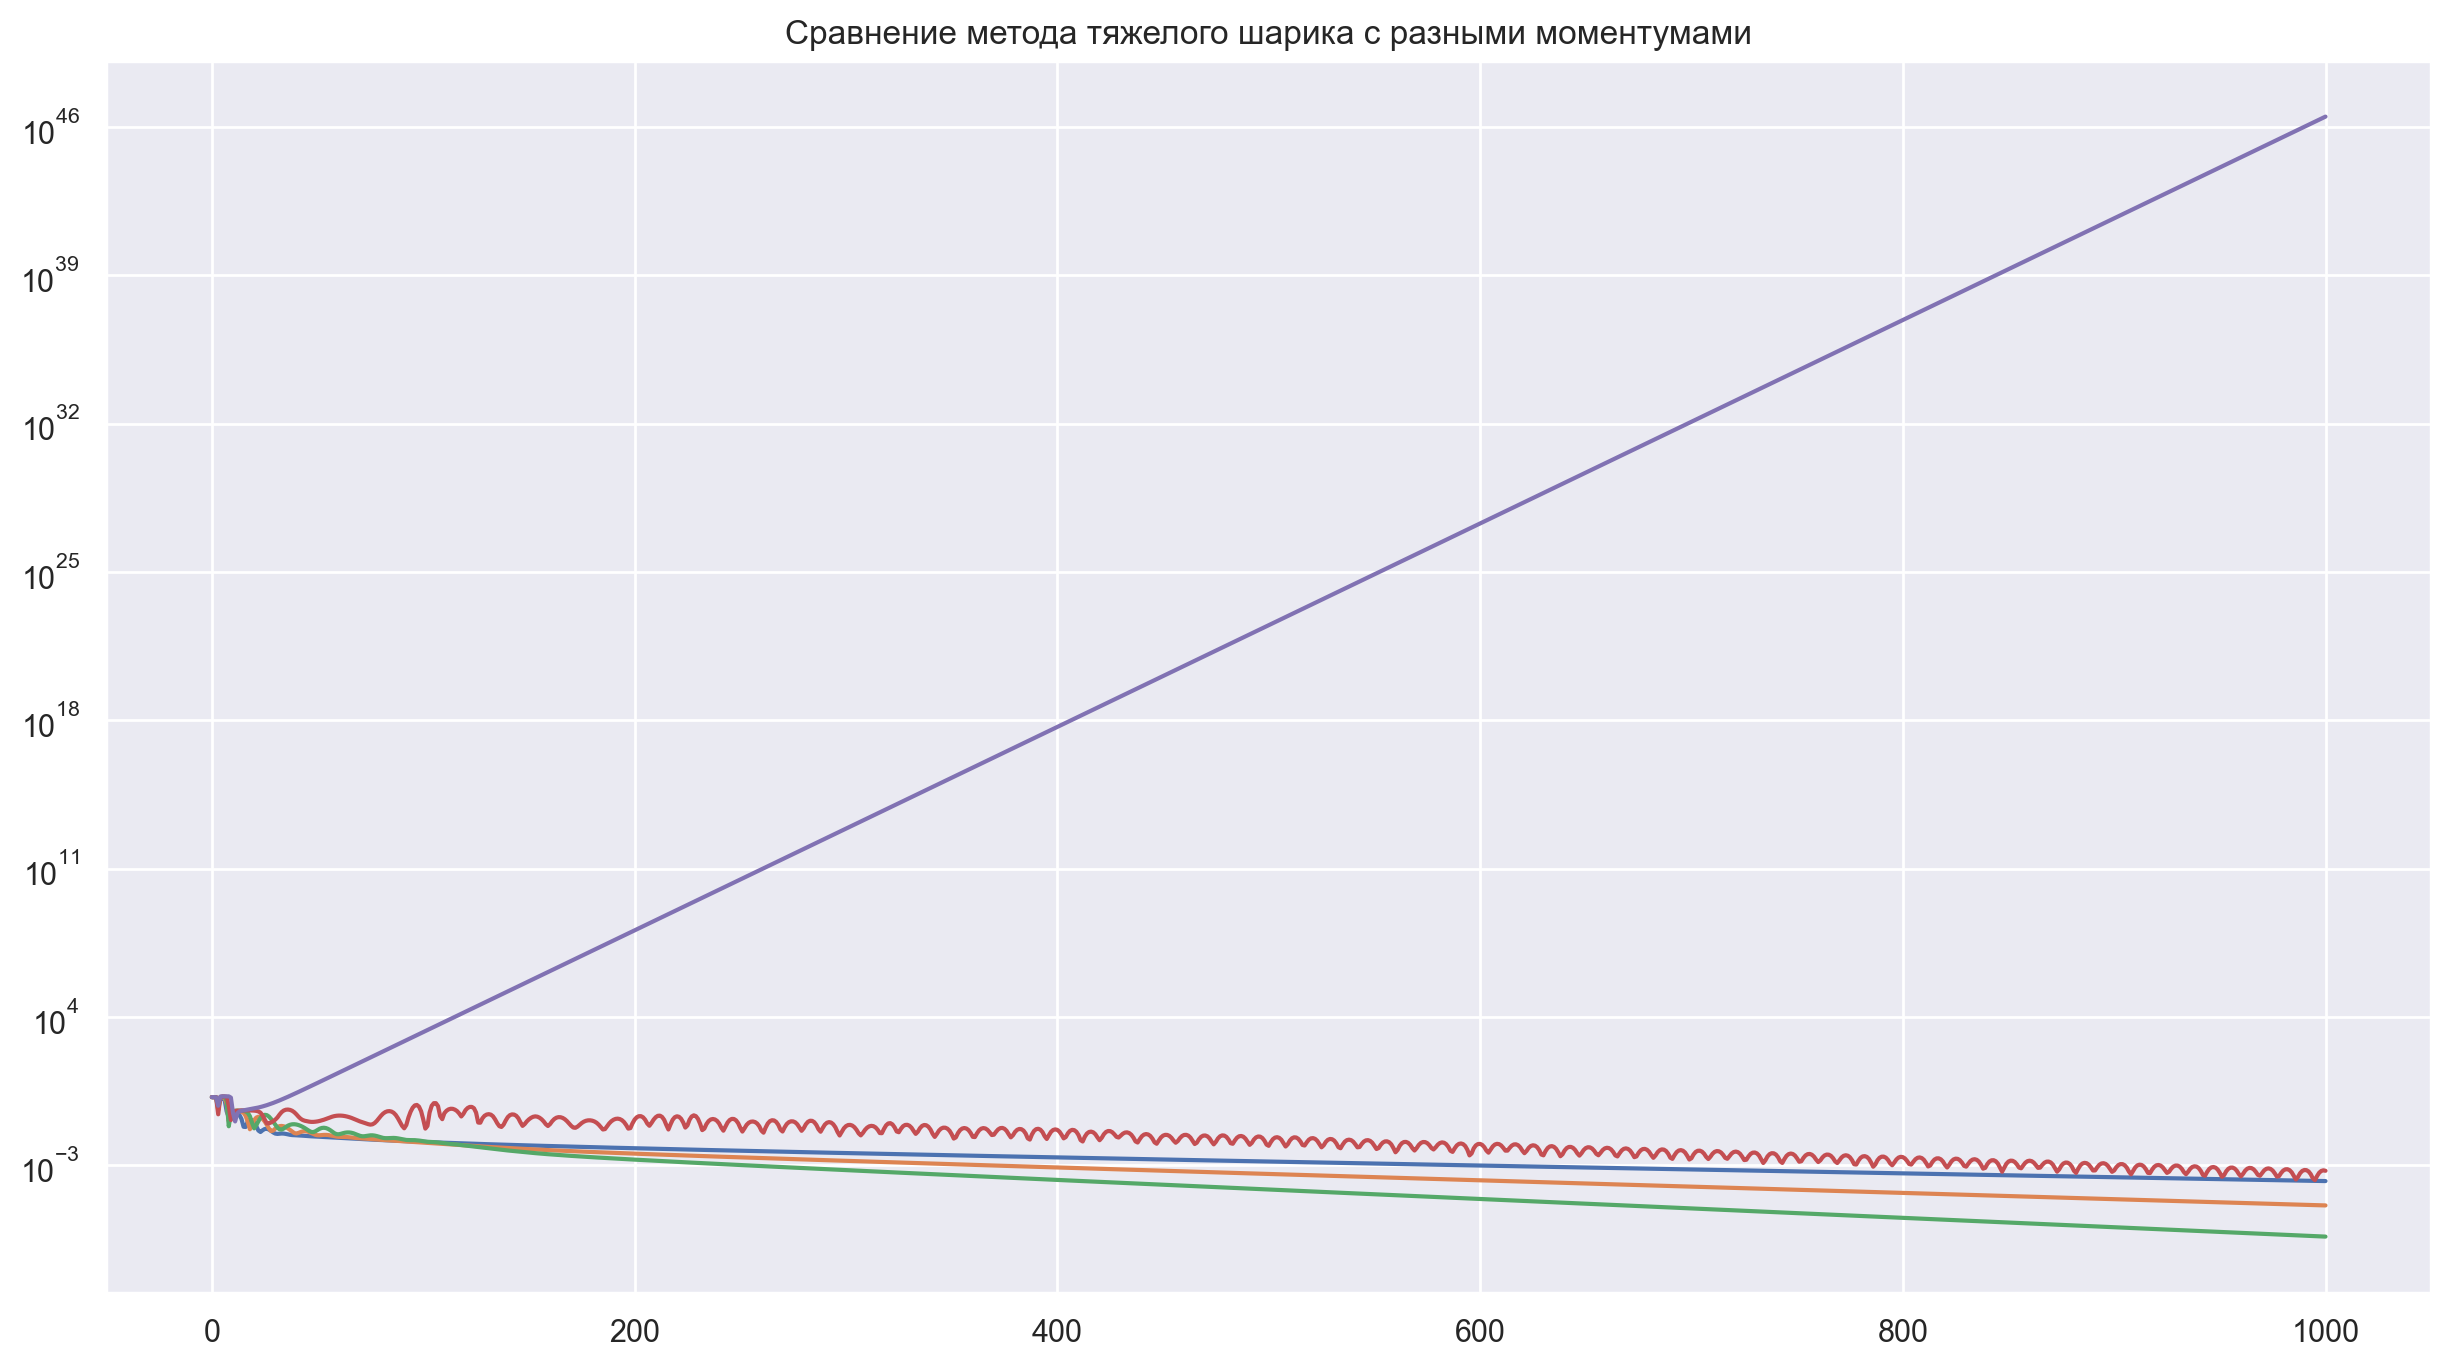

In [283]:
plt.figure(figsize = (15 ,8))

for i, tau_i in enumerate(tau_list):
  x_k, values, errors = heavy_ball(A_train, b_train, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=lambda x : gamma, tau=lambda x : tau_i)
  grid = np.arange(len(errors))
  plt.plot(grid, errors, label=tau_label_list[i])
  plt.yscale("log")
plt.title("Сравнение метода тяжелого шарика с разными моментумами")

 57%|█████▋    | 572/1000 [00:01<00:01, 314.80it/s]


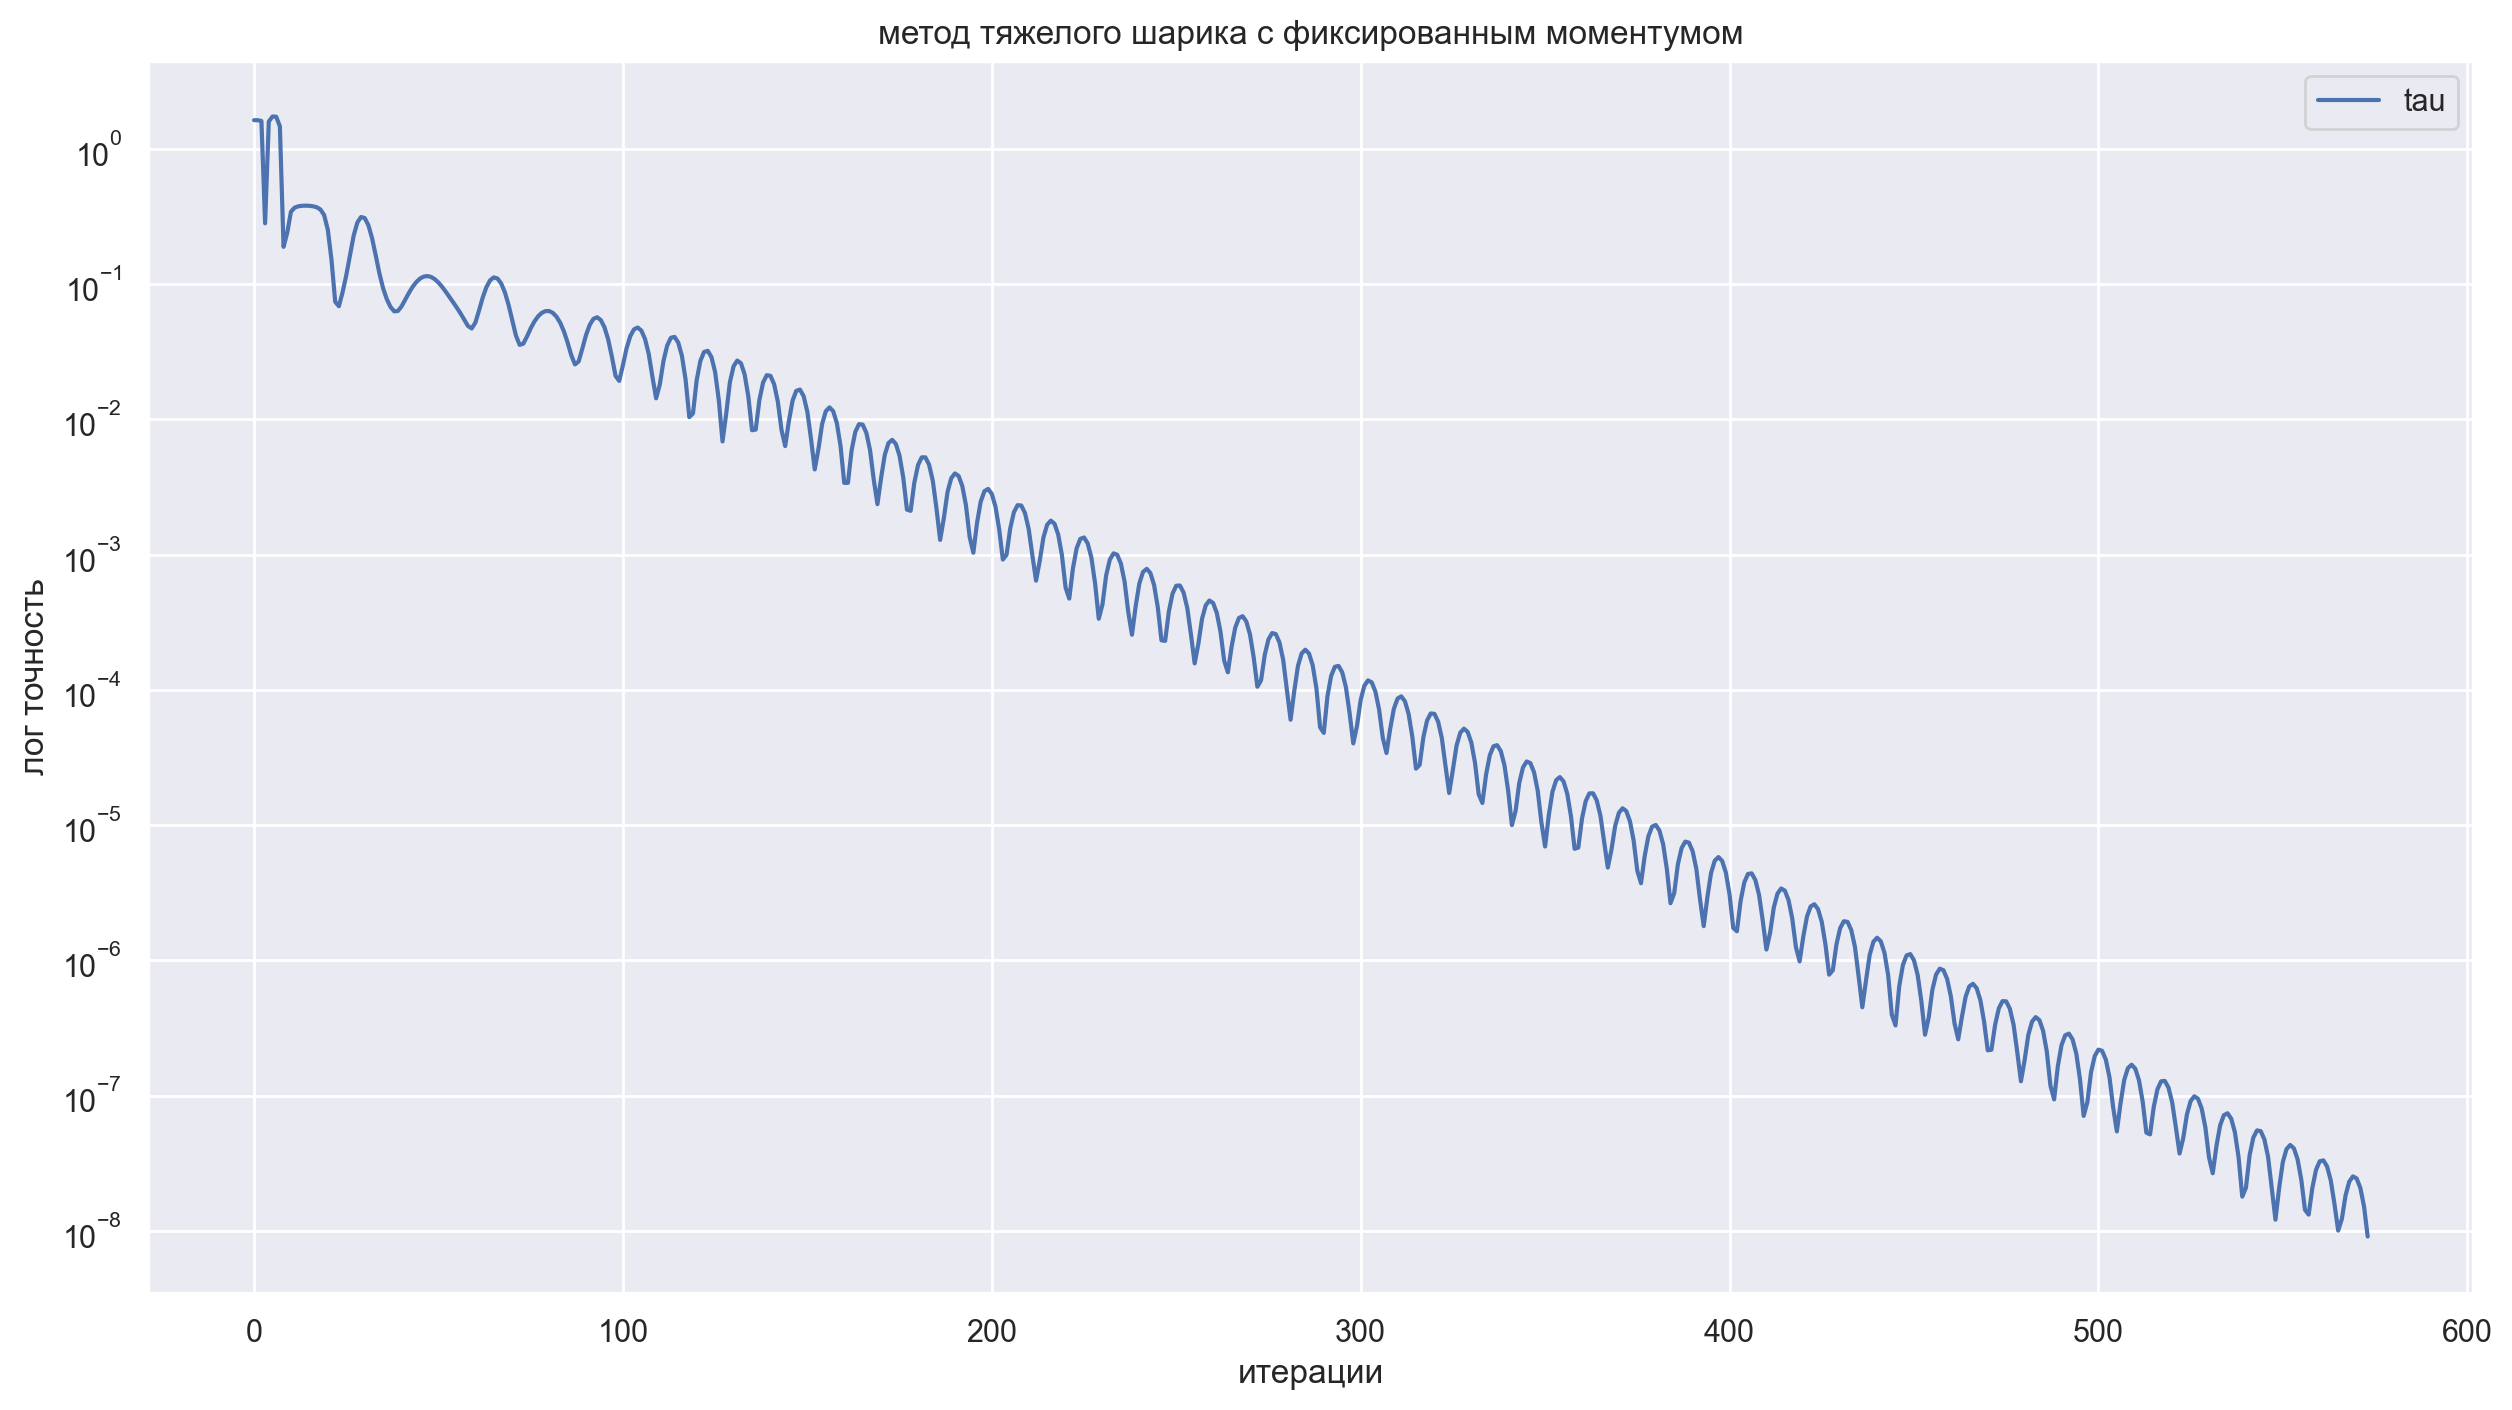

In [284]:
plt.figure(figsize = (15 ,8))

x_k, values, errors = heavy_ball(A_train, b_train, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=lambda x : gamma, tau=lambda x : tau)
grid = np.arange(len(errors))
plt.plot(grid, errors, label="tau")
plt.yscale("log")
plt.legend()
plt.xlabel("итерации")
plt.ylabel("лог точность")
plt.title("метод тяжелого шарика с фиксированным моментумом")
plt.show()

Можно заметить что разные вариации домнажения tau на разные коэфицента не хорошо влияют на метод, черезмерное увеличение tau приводит к расхождению метода

__б) (1 балл)__ Постройте сравнительный график, только теперь значение моментума будут зависеть от номера итерации. Сравните сходимости при
- $\tau = \frac{k}{k + 20}$;
- $\tau = \frac{k}{k + 10}$;
- $\tau = \frac{k}{k + 5}$;
- $\tau = \frac{k}{k + 1}$;
- Наилучший $\tau = const$.

In [285]:
tau = (np.sqrt(L) - np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu))
tau_k_list = [lambda k : k / (k + 20), lambda k : k / (k + 10), lambda k : k / (k + 5), lambda k : k / (k + 1), lambda k : tau]
tau_k_label_list = ["k / (k + 20)", "k / (k + 10)", "k / (k + 5)", "k / (k + 1)", "tau"]

lambda_value = L / 1000
gamma = 1/L
max_iter = 1000
eps = 1e-8

 57%|█████▋    | 572/1000 [00:01<00:01, 324.58it/s]


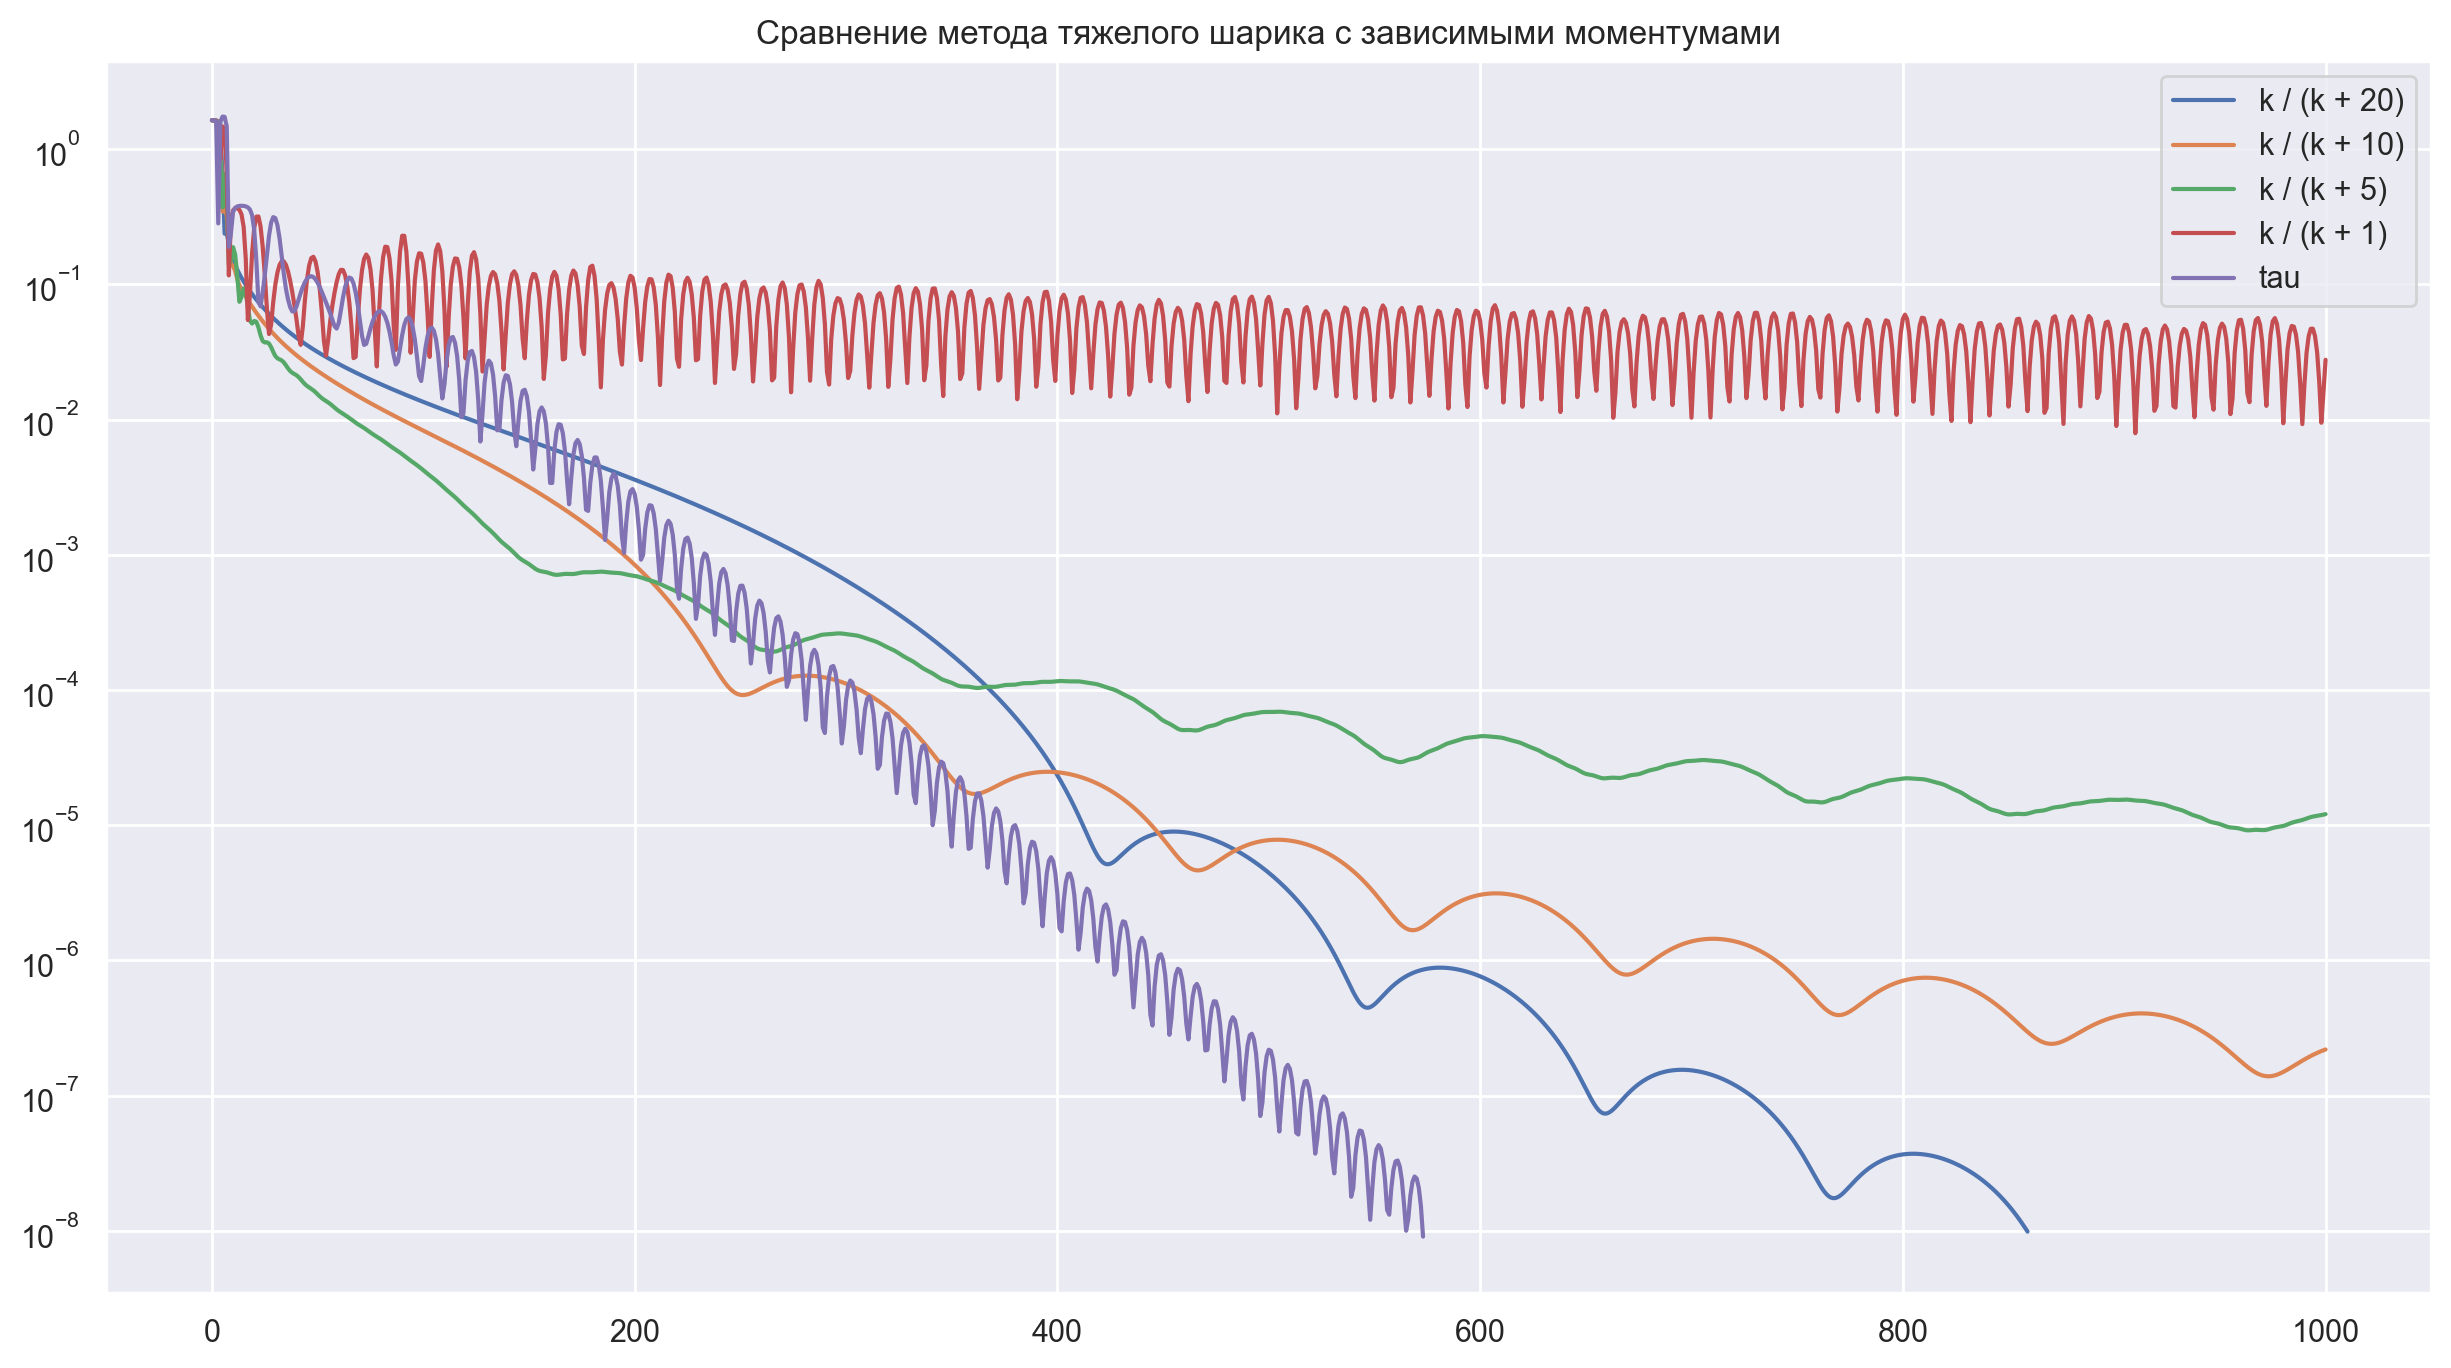

In [286]:
plt.figure(figsize = (15 ,8))

for i, tau_i in enumerate(tau_k_list):
  x_k, values, errors = heavy_ball(A_train, b_train, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=lambda x : gamma, tau=tau_i)
  grid = np.arange(len(errors))
  plt.plot(grid, errors, label=tau_k_label_list[i])
plt.title("Сравнение метода тяжелого шарика с зависимыми моментумами")
plt.yscale("log")
plt.legend()

Хоть этим моментумам и близко не подобратся к фиксированному tau, в отличие от предыдущих фиксированных вариантов, сходятся получше. (хотя $\frac{k}{k+1} -$ не сильно лучше)

__в) (1 балл)__ Сравните метод тяжелого шарика с обычным градиентным спуском. Для этого реализуйте метод градиентного спуска, а сравнения проведите для лучшего значение моментума в методе тяжелого шарика со следующими значениями шагов (для каждого из методов):

- $\gamma_k = \frac{1}{2L}$,

- $\gamma_k = \frac{1}{L}$,

- $\gamma_k = \frac{2}{L}$,

- $\gamma_k = \frac{2}{\mu + L}$.



In [287]:
def gradient_descent(A, b, lambda_value, grad, criterion, x_0, eps, max_iter, **params):
    """
    Реализация градиентного спуска.

    Параметры:
        A (np.array): Матрица признаков.
        b (np.array): Вектор целевых значений
        lambda_value (float): Параметр регуляризации
        grad (Callable): Функция вычисления градиента
        criterion (Callable): Функция критерия остановки
        x_0 (np.array): Начальная точка
        eps (float): Точность сходимости (критерий остановки)
        max_iter (int): Максимальное количество итераций
        params : Именованные гиперпараметры метода
            params['gamma'] : шаг на k-ой итерации

    Возвращает:
        x_k (np.array) : Найденное решение
        values (list) : Список значений x_k на каждой итерации
        errors (list) : Список значений критерия сходимости на каждой итерации
    """
    values = []
    errors = []

    x_k = np.copy(x_0)
    values.append(x_k)
    errors.append(criterion(x_k, A, b, lambda_value))

    for k in tqdm(range(max_iter)):
        gamma = params["gamma"]
        x_k -= gamma(k) * grad(x_k, A, b, lambda_value)

        values.append(x_k.copy())
        errors.append(criterion(x_k, A, b, lambda_value))
        if errors[-1] < eps:
            break

    return x_k, values, errors

 57%|█████▋    | 572/1000 [00:01<00:01, 325.51it/s]


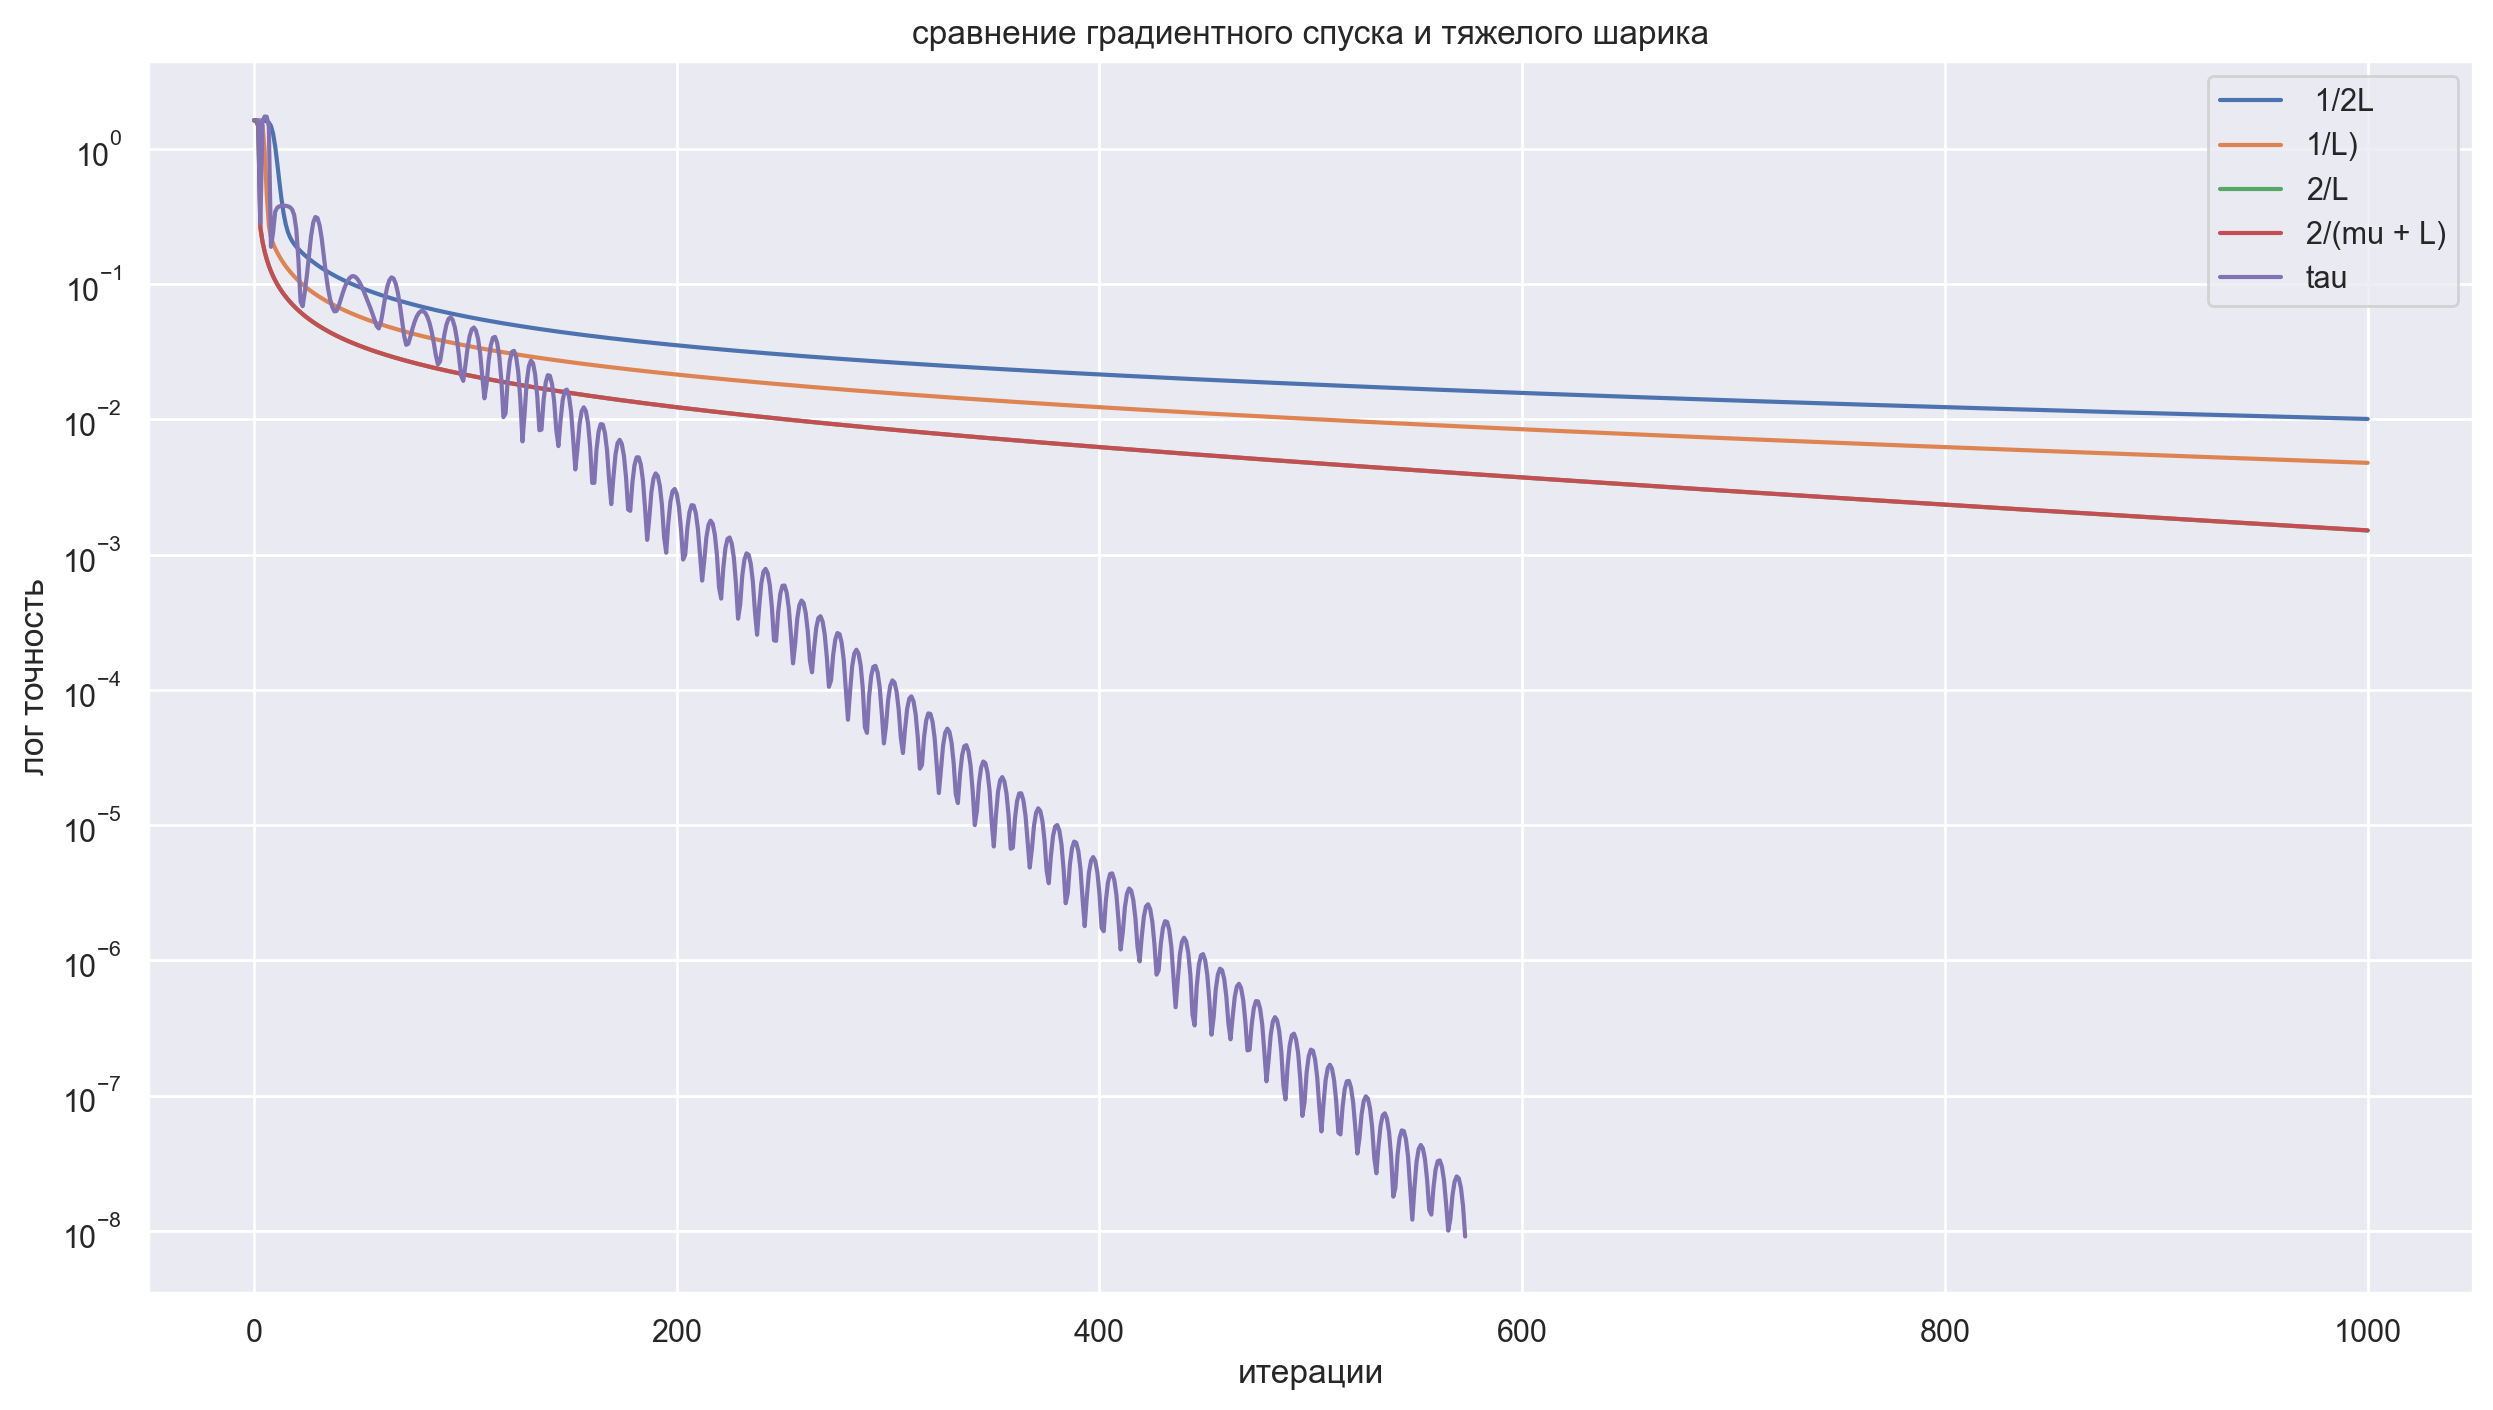

In [288]:
tau = (np.sqrt(L) - np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu))
lambda_list = [lambda k : (1/2) / L, lambda k : 1 / L, lambda k : 2 / L, lambda k : 2 / (mu + L)]
lambda_label_list = [" 1/2L", "1/L)", "2/L", "2/(mu + L)"]
lambda_value = L / 1000
gamma = 1/L
max_iter = 1000
eps = 1e-8

plt.figure(figsize = (15 ,8))

for i, gamma_i in enumerate(lambda_list):
  x_k, values, errors = gradient_descent(A, b, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=gamma_i)
  grid = np.arange(len(errors))
  plt.plot(grid, errors, label=lambda_label_list[i])

x_k, values, errors = heavy_ball(A_train, b_train, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=lambda x : gamma, tau=lambda x : tau)
grid = np.arange(len(errors))
plt.plot(grid, errors, label="tau")
plt.yscale("log")
plt.title("сравнение градиентного спуска и тяжелого шарика")
plt.legend()
plt.xlabel("итерации")
plt.ylabel("лог точность")
plt.show()

метод тяжелого шарика показывает себя отлично по сравнению с градиентным спуском

__г) (1.5 балла)__ Реализуйте ускоренный градиентный метод.

**Псевдокод алгоритма**

---

_Инициализация:_

- Размер шага $\{ \gamma_k \}_{k=0} > 0$
- Параметр момента $\{ \tau_k \}_{k=0} \in [0, 1]$
- Начальная точка $x^0 = x^{-1} \in \mathbb{R}^d$
- Максимальное число итераций $K$

---

$k$_-ая итерация_:

1. Обновить точку для следующего градиента:
   $$y^k = x^k + \tau_k \left(x^k - x^{k - 1} \right)$$

2. Сделать шаг градиентного спуска:
   $$x^{k+1} = y^k - \gamma_k \nabla f \left(y^k \right)$$

---

_Условие остановки:_
- Достигнуто максимальное число итераций $K$ или $\| \nabla f \left(x^k\right) \| < \varepsilon$

---

_Выход:_
- Полученное значение $x^K$

In [289]:
def NAG(A, b, lambda_value, grad, criterion, x_0, eps, max_iter, **params):
    """
    Реализация метода ускоренного градиента Нестерова.

    Параметры:
        A (np.array): Матрица признаков
        b (np.array): Вектор целевых значений
        lambda_value (float): Параметр регуляризации
        grad (Callable): Функция вычисления градиента в точке
        criterion (Callable): Функция критерия остановки
        x_0 (np.array): Начальная точка оптимизации
        eps (float): Точность сходимости (критерий остановки)
        max_iter (int): Максимальное количество итераций
        params : Именованные гиперпараметры метода
            params['gamma'](k) : функция шага на k-ой итерации
            params['tau'](k) : функция момента на k-ой итерации

    Возвращает:
        x_k (np.array) : Найденное решение
        values (list) : Список значений x_k на каждой итерации
        errors (list) : Список значений критерия сходимости на каждой итерации
    """
    values = []
    errors = []

    x_k = np.copy(x_0)
    x_k_old = np.copy(x_0)
    values.append(x_k)
    errors.append(criterion(x_k, A, b, lambda_value))

    y = np.copy(x_0)
    for k in tqdm(range(max_iter)):
        gamma = params["gamma"]
        tau = params["tau"]
        y = x_k + tau(k) * (x_k - x_k_old)
        x_k_old = x_k
        x_k = y - gamma(k) * grad(y, A, b, lambda_value)
        
        values.append(x_k)
        errors.append(criterion(x_k, A, b, lambda_value))
        if errors[-1] < eps:
            break

    return x_k, values, errors

Сравните его с методом тяжёлого шарика при тех же значениях моментума, что и в пункте __а)__.

  0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/5d/bsm3kt3d4qdc55zn6zggxf800000gq/T/ipykernel_97182/4051804021.py:11: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))
100%|██████████| 1000/1000 [00:03<00:00, 333.11it/s]


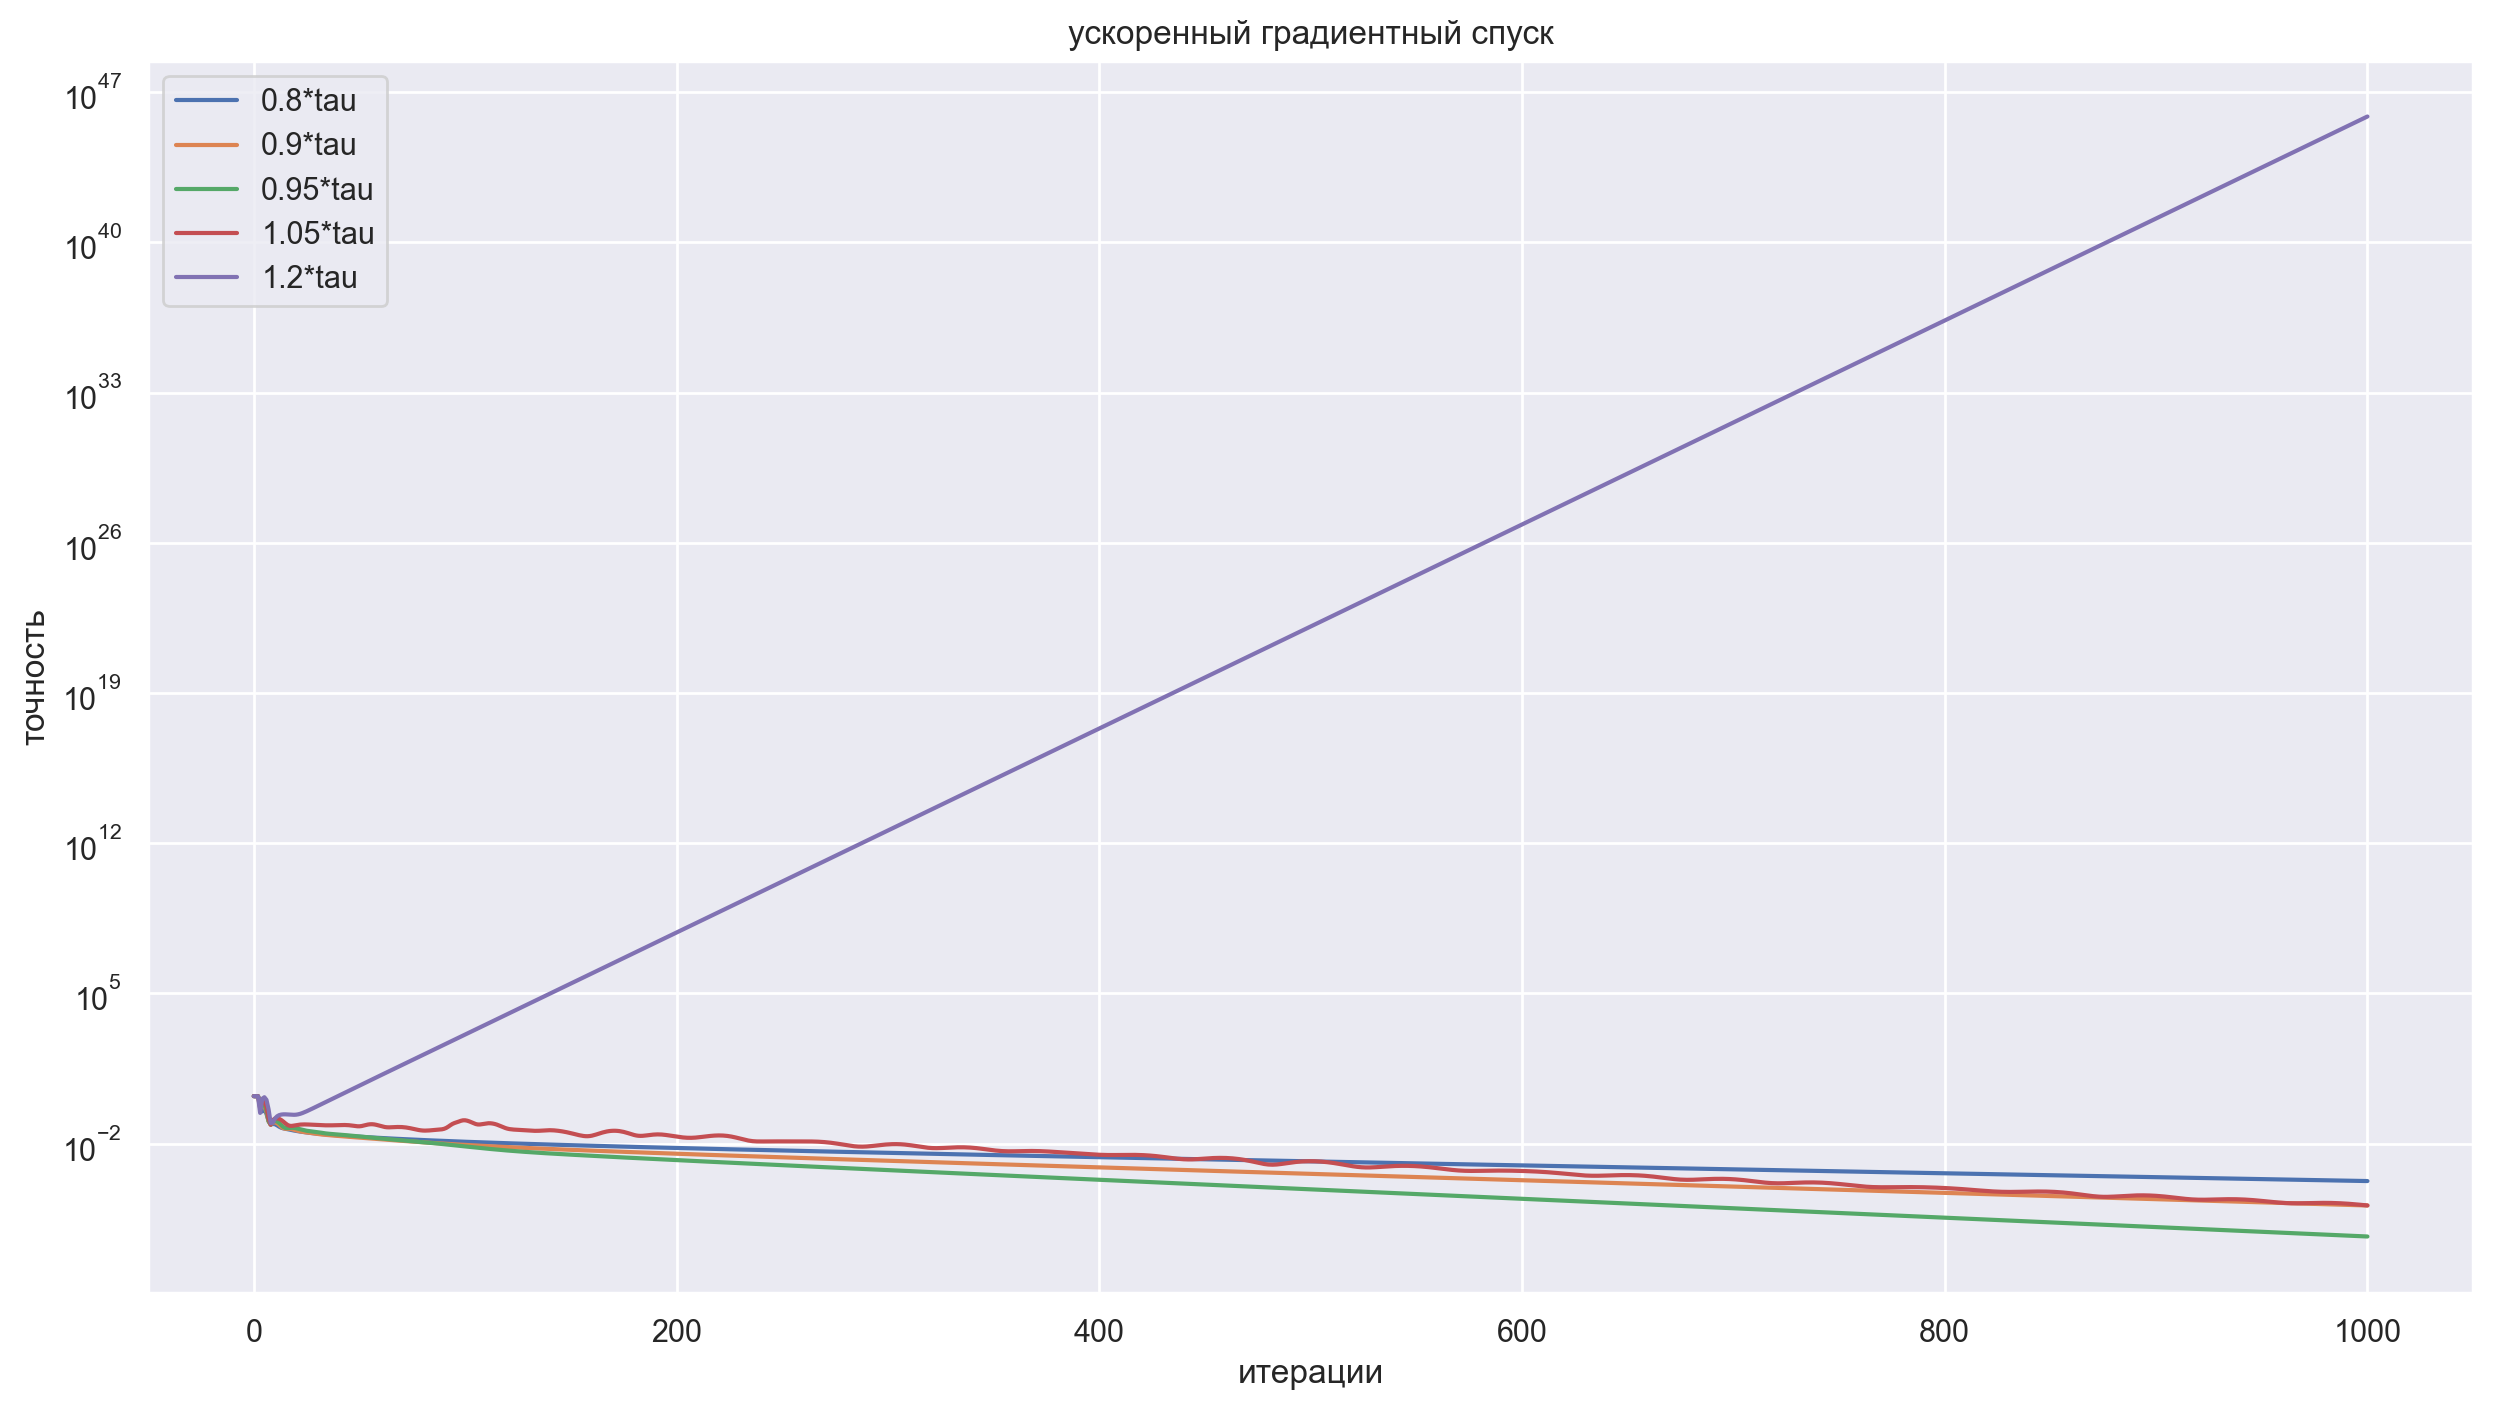

In [290]:
tau = (np.sqrt(L) - np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu))
tau_list = [0.8*tau, 0.9*tau, 0.95*tau, 1.05*tau, 1.2*tau]
tau_label_list = ["0.8*tau", "0.9*tau", "0.95*tau", "1.05*tau", "1.2*tau"]

lambda_value = L / 1000
gamma = 1/L
max_iter = 1000
eps = 1e-8

plt.figure(figsize = (15 ,8))

for i, tau_i in enumerate(tau_list):
  x_k, values, errors = NAG(A_train, b_train, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=lambda x : gamma, tau=lambda x : tau_i)
  grid = np.arange(len(errors))
  plt.plot(grid, errors, label=tau_label_list[i])
plt.title("ускоренный градиентный спуск")
plt.xlabel("итерации")
plt.ylabel("точность")
plt.yscale("log")
plt.legend()
plt.show()

1.2tau - расходится слишком сильно, посмотрим на NAG c оставшимися моментумами вместе с tau

 52%|█████▏    | 523/1000 [00:01<00:01, 355.92it/s]


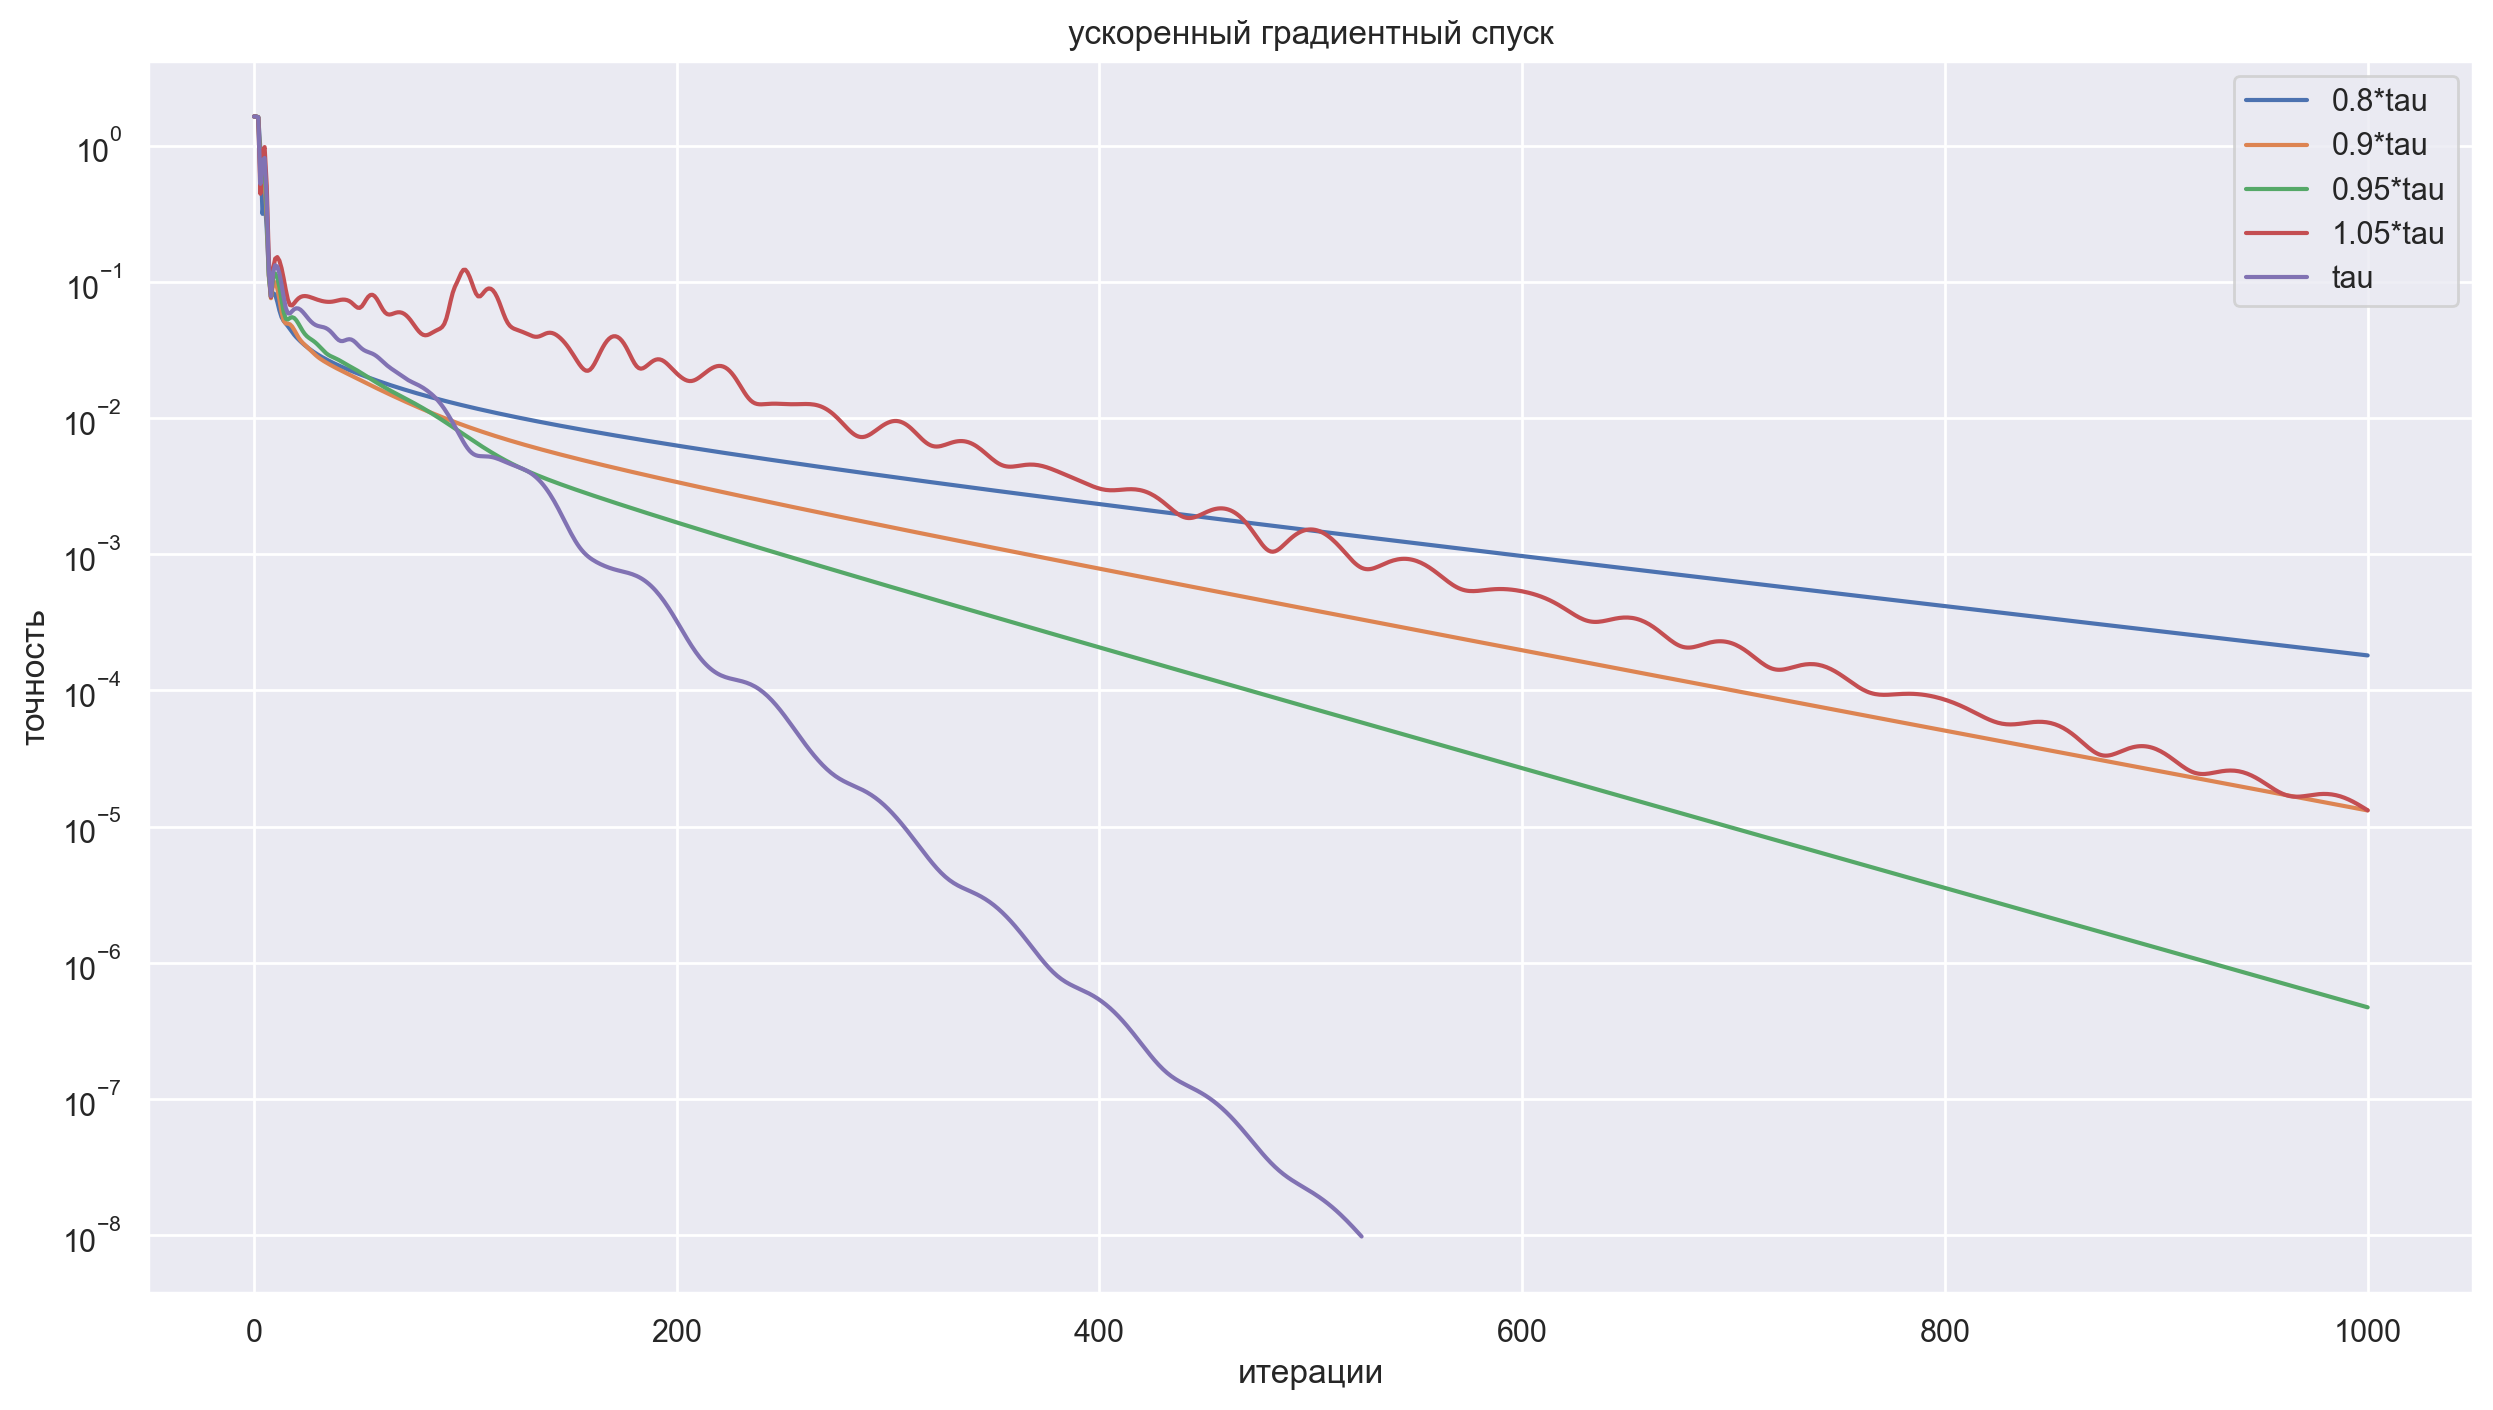

In [291]:
tau = (np.sqrt(L) - np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu))
tau_list = [0.8*tau, 0.9*tau, 0.95*tau, 1.05*tau, tau]
tau_label_list = ["0.8*tau", "0.9*tau", "0.95*tau", "1.05*tau", "tau"]

lambda_value = L / 1000
gamma = 1/L
max_iter = 1000
eps = 1e-8

plt.figure(figsize = (15 ,8))

for i, tau_i in enumerate(tau_list):
  x_k, values, errors = NAG(A_train, b_train, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=lambda x : gamma, tau=lambda x : tau_i)
  grid = np.arange(len(errors))
  plt.plot(grid, errors, label=tau_label_list[i])
plt.title("ускоренный градиентный спуск")
plt.xlabel("итерации")
plt.ylabel("точность")
plt.yscale("log")
plt.legend()
plt.show()

Ускоренный градиентный спуск орабатывает хорошо, даже лучше метода тяжелого шарика с лучшим параметром

 52%|█████▏    | 523/1000 [00:01<00:01, 353.25it/s]


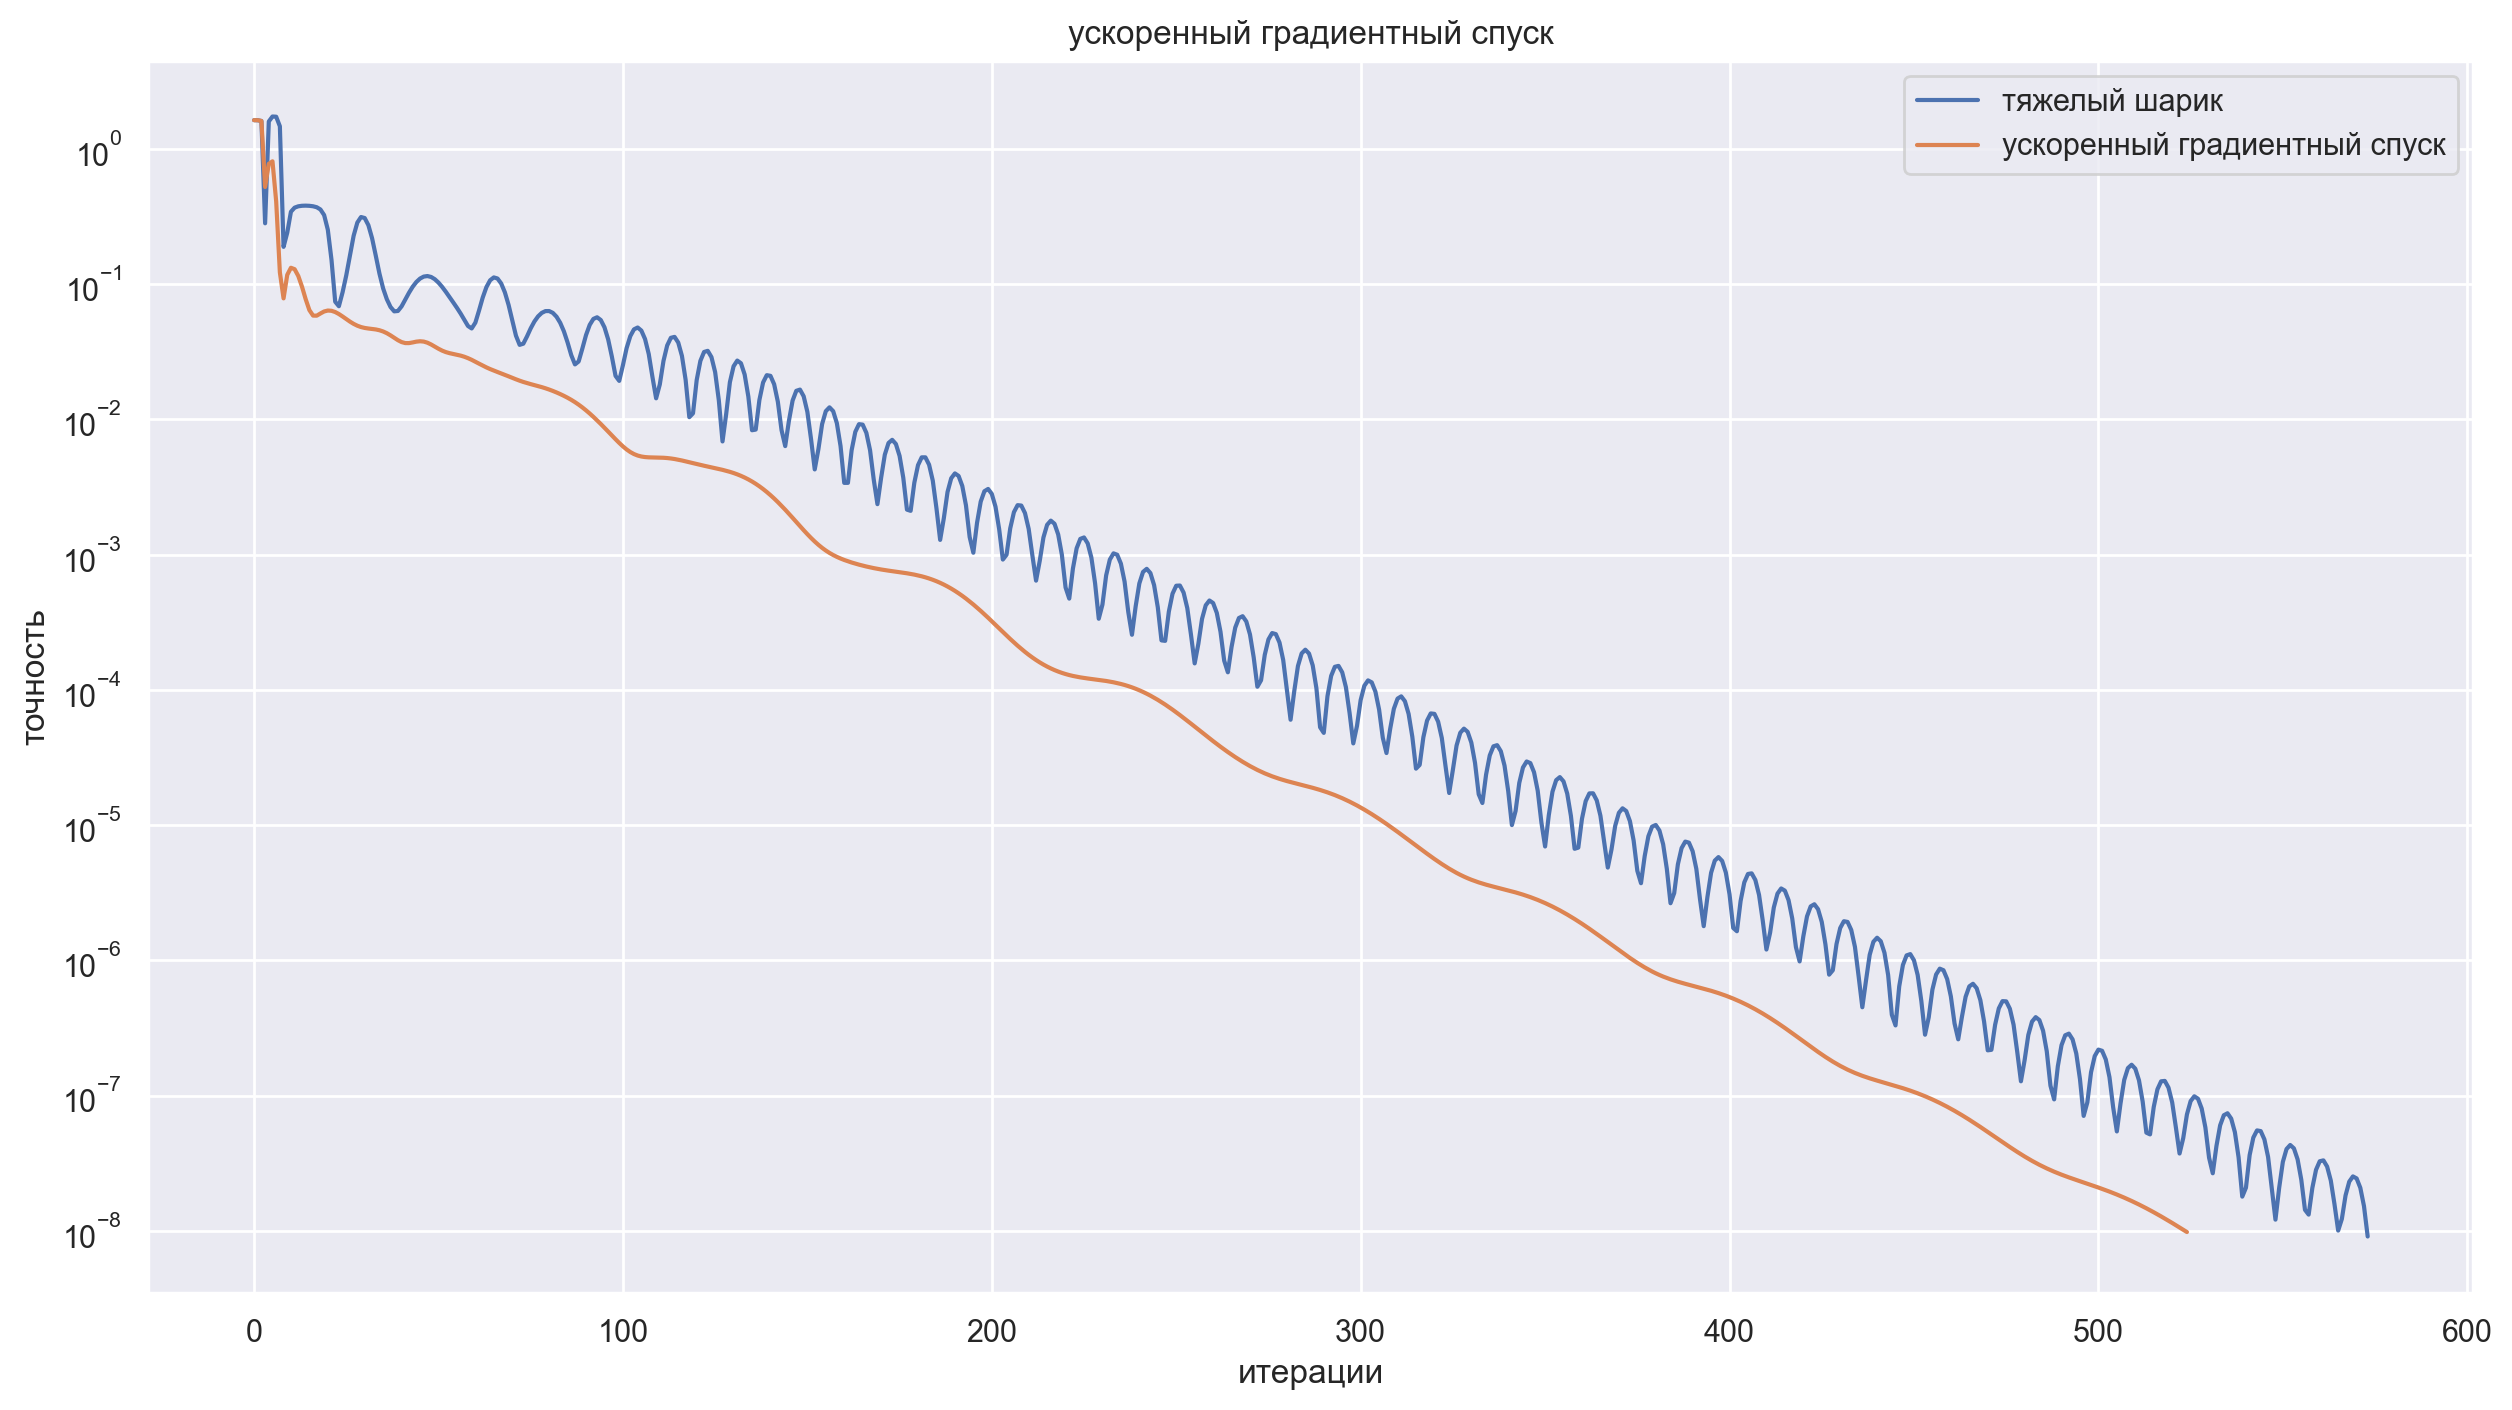

In [292]:
tau = (np.sqrt(L) - np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu))
lambda_value = L / 1000
gamma = 1/L
max_iter = 1000
eps = 1e-8

plt.figure(figsize = (15 ,8))

x_k, values, errors = heavy_ball(A_train, b_train, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=lambda x : gamma, tau=lambda x : tau)
grid = np.arange(len(errors))
plt.plot(grid, errors, label="тяжелый шарик")

x_k, values, errors = NAG(A_train, b_train, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=lambda x : gamma, tau=lambda x : tau)
grid = np.arange(len(errors))
plt.plot(grid, errors, label="ускоренный градиентный спуск")

plt.title("ускоренный градиентный спуск")
plt.xlabel("итерации")
plt.ylabel("точность")
plt.yscale("log")
plt.legend()
plt.show()

__д) (0.5 балла)__ Наблюдать уменьшение критерия сходимости, конечно, замечательно, но хочется провалидироваться на тестовых данных. Для этого необходимо подсчитать отношение правильно предсказанных меток классов к их общему числу (метрика _accuracy_). Предложите способ, как оценить значение этой метрики. Помните, что функция $g(x, a_i)$ возвращает значение в диапазоне от 0 до 1.

пусть наша модель дает вероятности $p = g(x, a)$. Предсказываем класс как 1, если $p >= 0.5$, иначе 0. 

Тогда accuracy = $\frac{число верных предсказаний}{число}$ объектов.

__е) (1 балл)__ Постройте графики значения метрики _accuracy_ для градиентного спуска, метода тяжёлого шарика и ускоренного градиентного спуска. Положите шаг равным $\frac{1}{L}$, а значение моментума подберите для каждого метода таким, на котором наблюдалась лучшая сходимость.

 52%|█████▏    | 523/1000 [00:01<00:01, 341.96it/s]


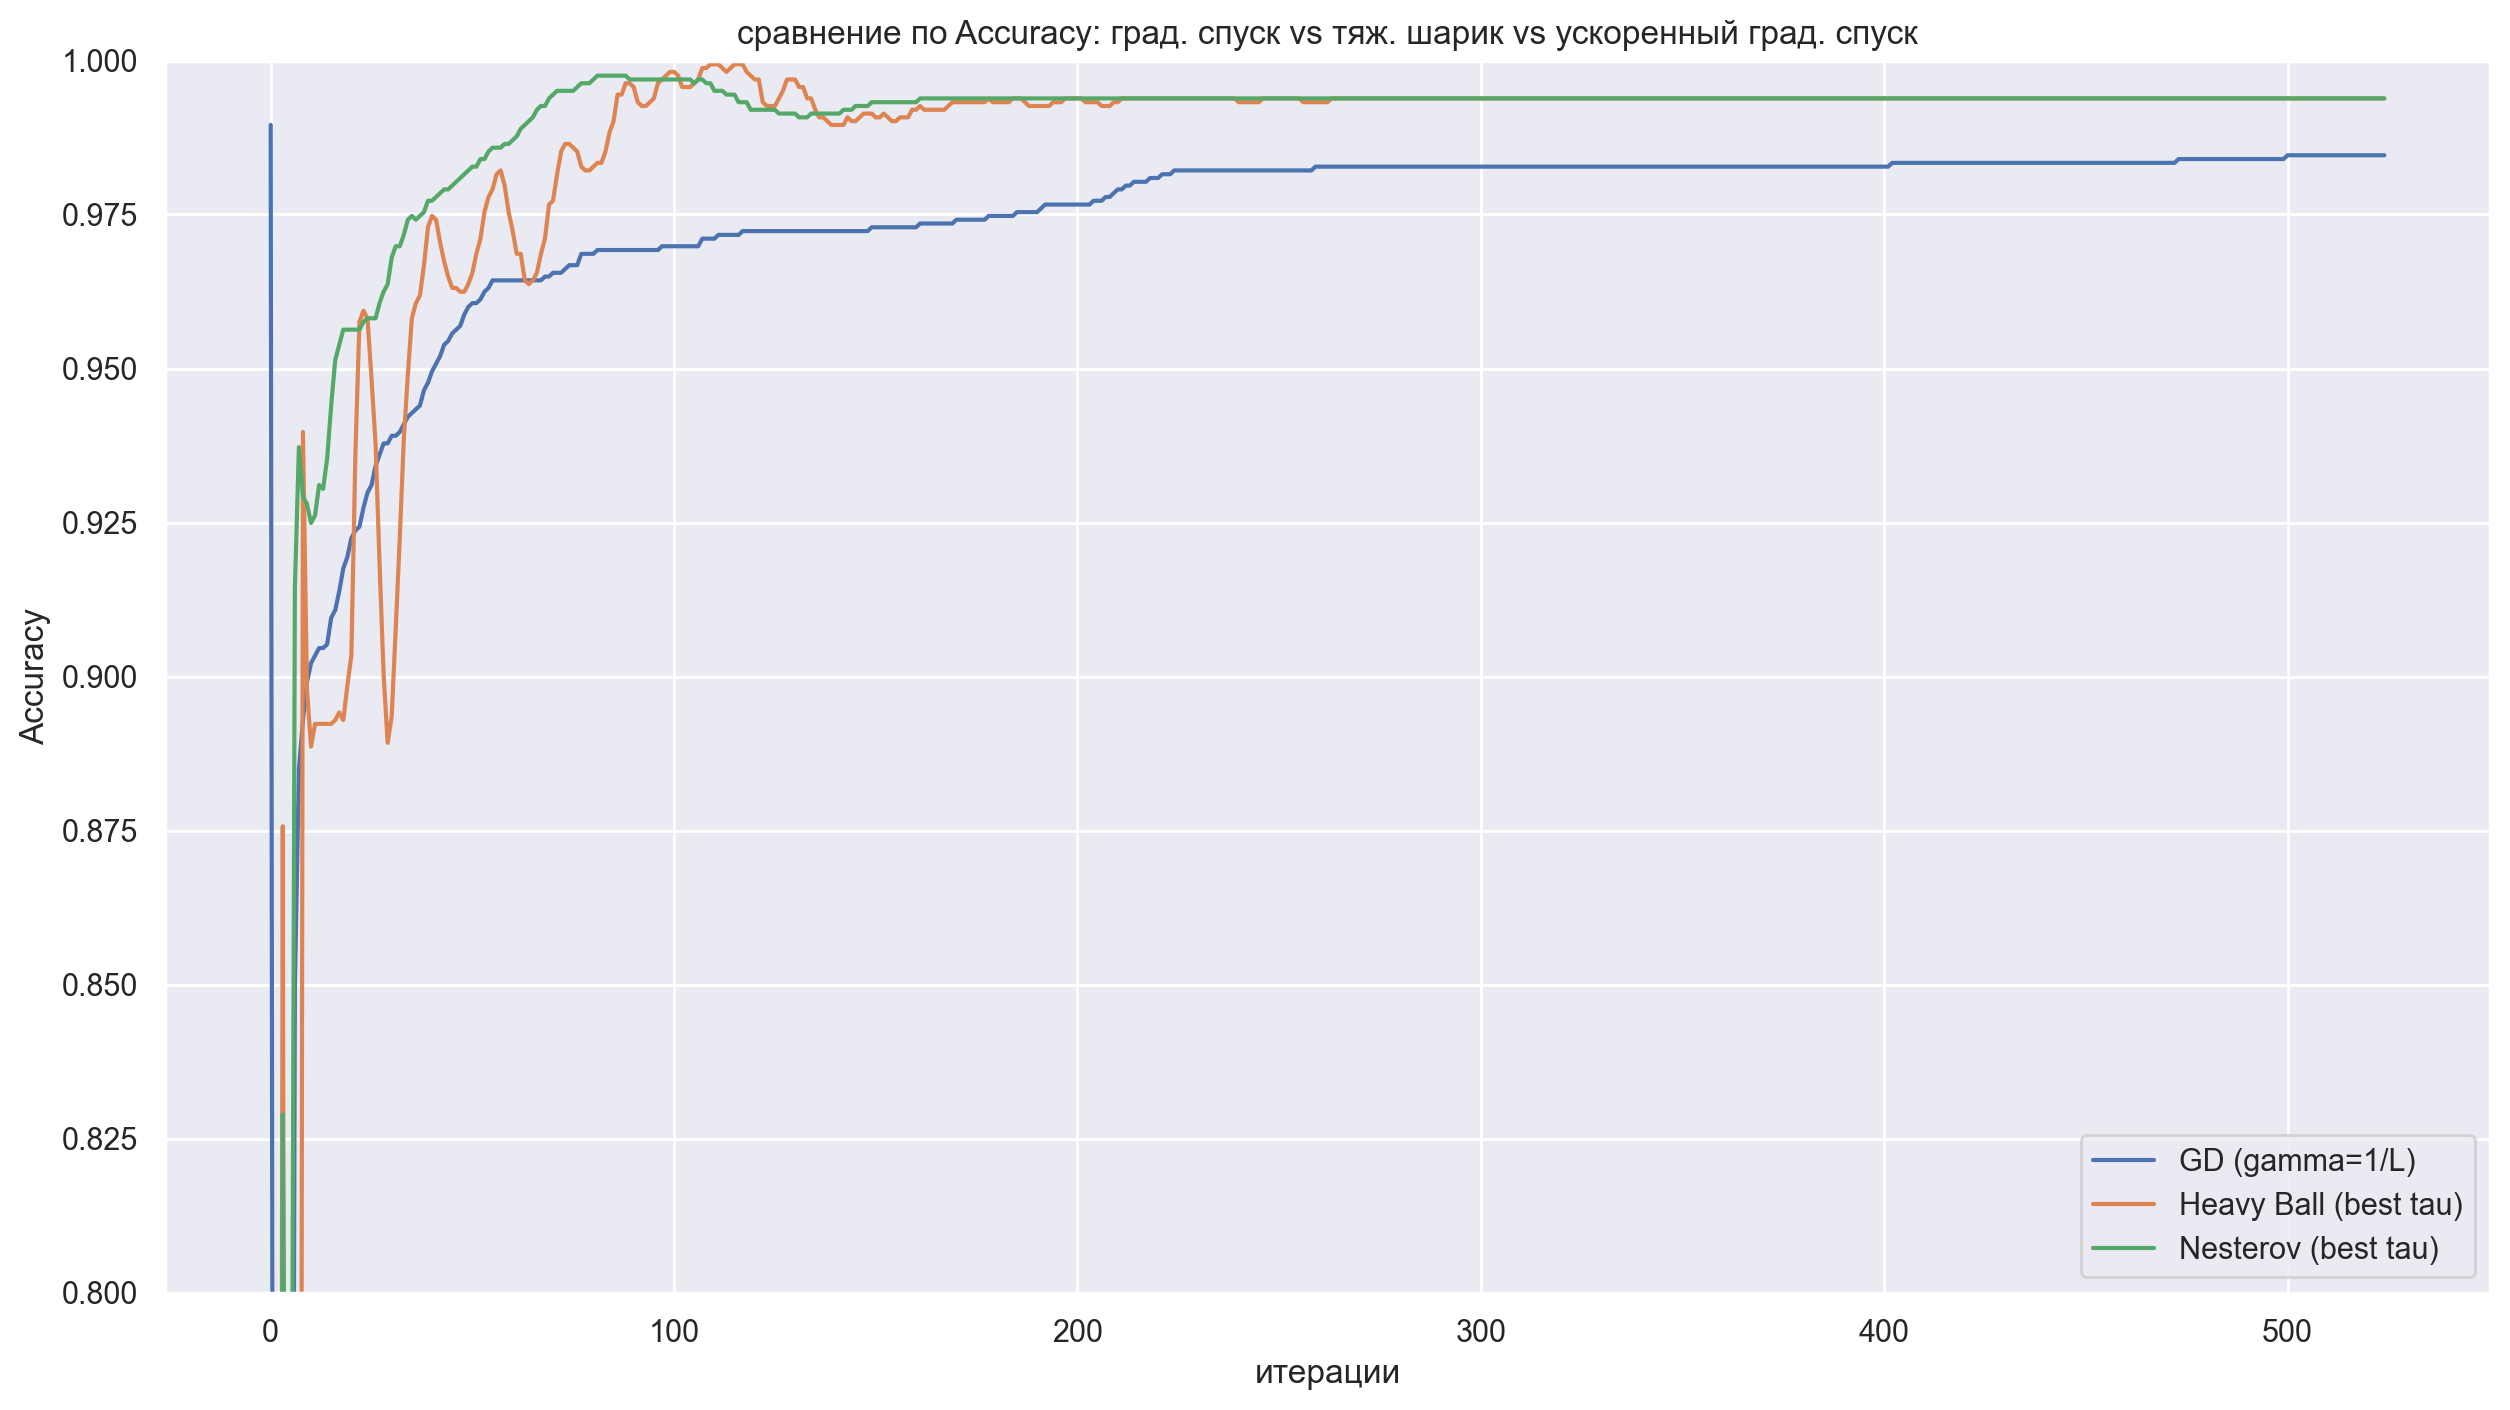

In [293]:
def accuracy_for_values(values, A_eval, b_eval):
  acc_list = []
  for x in values:
    p = sigmoid(A_eval @ x)
    y_hat = (p >= 0.5).astype(int)
    acc = (y_hat == b_eval).mean()
    acc_list.append(acc)
  return acc_list

best_tau = (np.sqrt(L) - np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu))
lambda_value = L / 1000
gamma = 1 / L
max_iter = 1000
eps = 1e-8

x_gd, values_gd, errors_gd = gradient_descent(A_train, b_train, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=lambda k: gamma)
x_hb, values_hb, errors_hb = heavy_ball(A_train, b_train, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=lambda k: gamma, tau=lambda k: best_tau)
x_nag, values_nag, errors_nag = NAG(A_train, b_train, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=lambda k: gamma, tau=lambda k: best_tau)

acc_gd = accuracy_for_values(values_gd, A_test, b_test)
acc_hb = accuracy_for_values(values_hb, A_test, b_test)
acc_nag = accuracy_for_values(values_nag, A_test, b_test)

m = min(len(acc_gd), len(acc_hb), len(acc_nag))
acc_gd, acc_hb, acc_nag = acc_gd[:m], acc_hb[:m], acc_nag[:m]

plt.figure(figsize=(15, 8))
plt.plot(np.arange(m), acc_gd, label="GD (gamma=1/L)")
plt.plot(np.arange(m), acc_hb, label=f"Heavy Ball (best tau)")
plt.plot(np.arange(m), acc_nag, label=f"Nesterov (best tau)")
plt.xlabel("итерации")
plt.ylabel("Accuracy")
plt.title("сравнение по Accuracy: град. спуск vs тяж. шарик vs ускоренный град. спуск")
plt.ylim(0.8, 1)
plt.legend()
plt.show()

## Дополнительная часть (10 баллов)

__Задача 3.__ До этого, в рамках метода градиентного спуска, мы использовали константный и зависящий от номера итерации шаг. В случае неоптимального подбора, алгоритм может требовать сильно большее число итераций для достижения сходимости. Отсюда возникает идея использовать шаги, которые бы зависели от некоторых параметров функции.

Сделаем так: будем искать такой шаг $\gamma_k$ в точке $x^k$, чтобы значение функции в следующей точке было достаточно малым (относительно текущей точки). В идеале, мы хотим решить следующее:

$$
\gamma_k = \arg \min_{\gamma_k} f \left(x^k + \gamma_k p^k \right),~ \text{где $p^k$ — это направление куда мы хотим двигаться.}
$$

Этот алгоритм в общем виде называется _линейный поиск_. Для градиентного спуска $p^k$ — это просто антиградиент.

Как нетрудно заметить, основная проблема заключается в том, что отрешивать $\arg \min$ на каждой итерации спуска — вычислительно сложная задача, которая хоть и даст улучшение по числу итераций, но сильно повысит временные затраты алгоритма. В данной задаче мы изучим различные методы поиска $\gamma_k$, которые начинают с некоторого стартового шага $\gamma_0$ и уменьшают его до тех пор, пока не выполнится необходимое условие приемлемости шага.

__а) (2 балла)__ Первым рассмотрим условие Армихо. Эта стратегия основывается на следующей идее: мы хотим из точки $x^k$ попасть в такую точку $x^{k+1}$, что значение функции в ней достаточно мало по сравнению со значением функции в текущей точке. Но под "достаточно мало" мы понимаем не просто уменьшение, а уменьшение с определённой скоростью, соответствующей направлению спуска. Чтобы это количественно формализовать, будем сравнивать значение функции в новой точке с значением касательной прямой, проведённой в точке $x^k$ в направлении $h^k$. Если новая точка оказывается ниже этой прямой — шаг подходит. Для надёжности наклон касательной немного уменьшают, домножая на коэффициент $c_1 \in (0, 1)$, чтобы не требовать слишком сильного убывания и избежать отбрасывания хороших шагов.

Из вышесказанного получается следующее условие:

$$
f\left(x^k + \gamma_k h^k\right) \leq f\left(x^k\right) + \beta_1 \gamma_k \langle \nabla f(x^k), h^k \rangle.
$$

Это неравенство можно получить, записав линейное приближение функции $f\left(x^k + \gamma_k h^k \right)$ до первого порядка разложения в точке $x^k$, и затем требуя, чтобы значение функции не просто уменьшилось, а оказалось ниже этого приближения с некоторым запасом.

В случае градиентного спуска $h^k = -\nabla f\left(x^k\right)$ неравенство принимает вид:

$$
f\left(x^k - \gamma_k \nabla f\left( x^k \right)\right) \leq f\left(x^k\right) - \beta_1 \gamma_k \left\| \nabla f\left(x^k\right) \right\|_2^2.
$$

Для удобства, допишите общий метод `gradient_descent_optimal_steps`, который будет принимать в себя различные правила поисков шага (`line_search`), а также напишите функцию `armijo`, вычисляющее приближенное значение $\gamma_k$ за определенное количество итераций.

**Псевдокод алгоритма**

---

_Инициализация:_

- Начальная точка $x^k$
- Начальная точка $\gamma_0 > 0$
- Направление спуска $h^k$
- Максимальное число итераций $K$
- Множитель уменьшения шага $m \in (0, 1)$
- Параметр $\beta_1 \in (0, 1)$

---

1. Проверить условие Армихо:

$$
f\left(x^k + \gamma_k h^k\right) \leq f\left(x^k\right) + \beta_1 \gamma_k \langle \nabla f(x^k), h^k \rangle
$$

2. Если условие выполнено — вернуть $\gamma_k$. Иначе — уменьшить шаг:

    $$
    \gamma_k = m \cdot \gamma_k
    $$

    и вернуться к 1.

---

_Условие остановки:_
- Достигнуто максимальное число итераций $K$

---

_Выход:_
- Полученное значение $\gamma_k$

In [294]:
def gradient_descent_optimal_steps(A, b, lambda_value, loss, grad, line_search, criterion, x_0, eps=1e-8, 
                                   max_iter=1000, **params):
    """
    Реализация градиентного спуска с оптимальным подбором шага.

    Параметры:
        A (np.array): Матрица признаков размерности
        b (np.array): Вектор целевых значений размерности
        lambda_value (float): Параметр регуляризации
        loss (Callable): Функция потерь
        grad (Callable): Функция вычисления градиента
        line_search (Callable): Функция подбора шага
        criterion (Callable): Функция критерия остановки
        x_0 (np.array): Начальная точка оптимизации
        eps (float): Точность сходимости (критерий остановки)
        max_iter (int): Максимальное количество итераций
        params (dict): Дополнительные параметры для line_search:
            params['beta1'] (float): Первый параметр (обычное 1e-4)
            params['beta2'] (float): Второй параметр (не используется в правиле Армихо)
            params['gamma_mult'] (float): Множитель для уменьшения шага (обычно 0.5)
            params['line_search_max_iter'] (int): Макс. итераций подбора шага (обычно 100)
            params['gamma0'] (float): Начальное значение шага (обычно 1e-2)

    Возвращает:
        x_k (np.array): Найденное решение
        values (list): История значений x на каждой итерации
        errors (list): История значений критерия сходимости
    """
    values = []
    errors = []

    x_k = np.copy(x_0)
    values.append(x_k)
    errors.append(criterion(x_k, A, b, lambda_value))
    gamma = np.copy(params["gamma0"])
    gamma_mult = params['gamma_mult']
    max_iters = params['line_search_max_iter']
    beta1 = params['beta1']
    beta2 = params['beta2']

    for k in tqdm(range(max_iter)):
        gamma = line_search(A, b, lambda_value, loss, grad, x_k, -grad(x_k, A, b, lambda_value), beta1, beta2, gamma_mult, max_iters, gamma)
        
        x_k -= gamma * grad(x_k, A, b, lambda_value)

        values.append(x_k)
        errors.append(criterion(x_k, A, b, lambda_value))
        if errors[-1] < eps:
            break

    return x_k, values, errors

$$
\min_{x \in \mathbb{R}^d} \left[ f(x) = \frac{1}{n} \sum_{i=1}^n \ell \left(g(x, a_i), b_i \right) + \frac{\lambda}{2} \| x \|^2_2 \right],
$$

$$
f\left(x^k + \gamma_k h^k\right) \leq f\left(x^k\right) + \beta_1 \gamma_k \langle \nabla f(x^k), h^k \rangle
$$

In [303]:
def armijo(A, b, lambda_value, loss, grad, x, h, beta1, beta2, gamma_mult, max_iters, gamma0):
    """
    Правило Армихо.

    Параметры:
        A (np.array): Матрица признаков
        b (np.array): Вектор целевых значений
        lambda_value (float): Параметр регуляризации
        loss (Callable): Функция потерь f(x)
        grad (Callable): Функция вычисления градиента ∇f(x)
        x (np.array): Текущая точка
        h (np.array): Направление спуска (обычно -∇f(x))
        beta1 (float): Параметр условия достаточного убывания (обычно 1e-4)
        beta2 (float): Не используется, оставлен для совместимости, по умолчанию 0
        gamma_mult (float): Множитель уменьшения шага (обычно 0.5)
        max_iters (int): Максимальное число итераций подбора (обычно 100)
        gamma0 (float): Начальное значение шага

    Возвращает:
        gamma (float): Найденное значение шага, удовлетворяющее условию Армихо
    """
    gamma = np.copy(gamma0)
    counter = 0
    current_loss = loss(x, A, b, lambda_value)
    grad_x = grad(x, A, b, lambda_value)
    directional_derivative = grad_x.dot(h)

    while counter < max_iters:
        first = loss(x + gamma * h, A, b, lambda_value)
        second = loss(x, A, b, lambda_value) + beta1*gamma*directional_derivative
        if(first <= second):
            break
        gamma = gamma_mult * gamma
        counter += 1
        
    return gamma

Запустите градиентный спуск с правилом Армихо, рассмотрев разные значения для начальной инициализации $\gamma_0$ и базовыми значениями для других параметров:
- $\gamma_0 = 10^{-2}$ — стандартное значение;
- $\gamma_0 = 10^{-1}$;
- $\gamma_0 = 1$;
- $\gamma_0 = 5$.
- $\gamma_0 = 10$.
- $\gamma_0 = 15$.

В качестве множителя уменьшения шага рассмотрите $m = 0.5$. В качестве параметра $\beta_1$ возьмите $\beta_1 = 10^{-4}$.

100%|██████████| 1000/1000 [00:07<00:00, 141.44it/s]


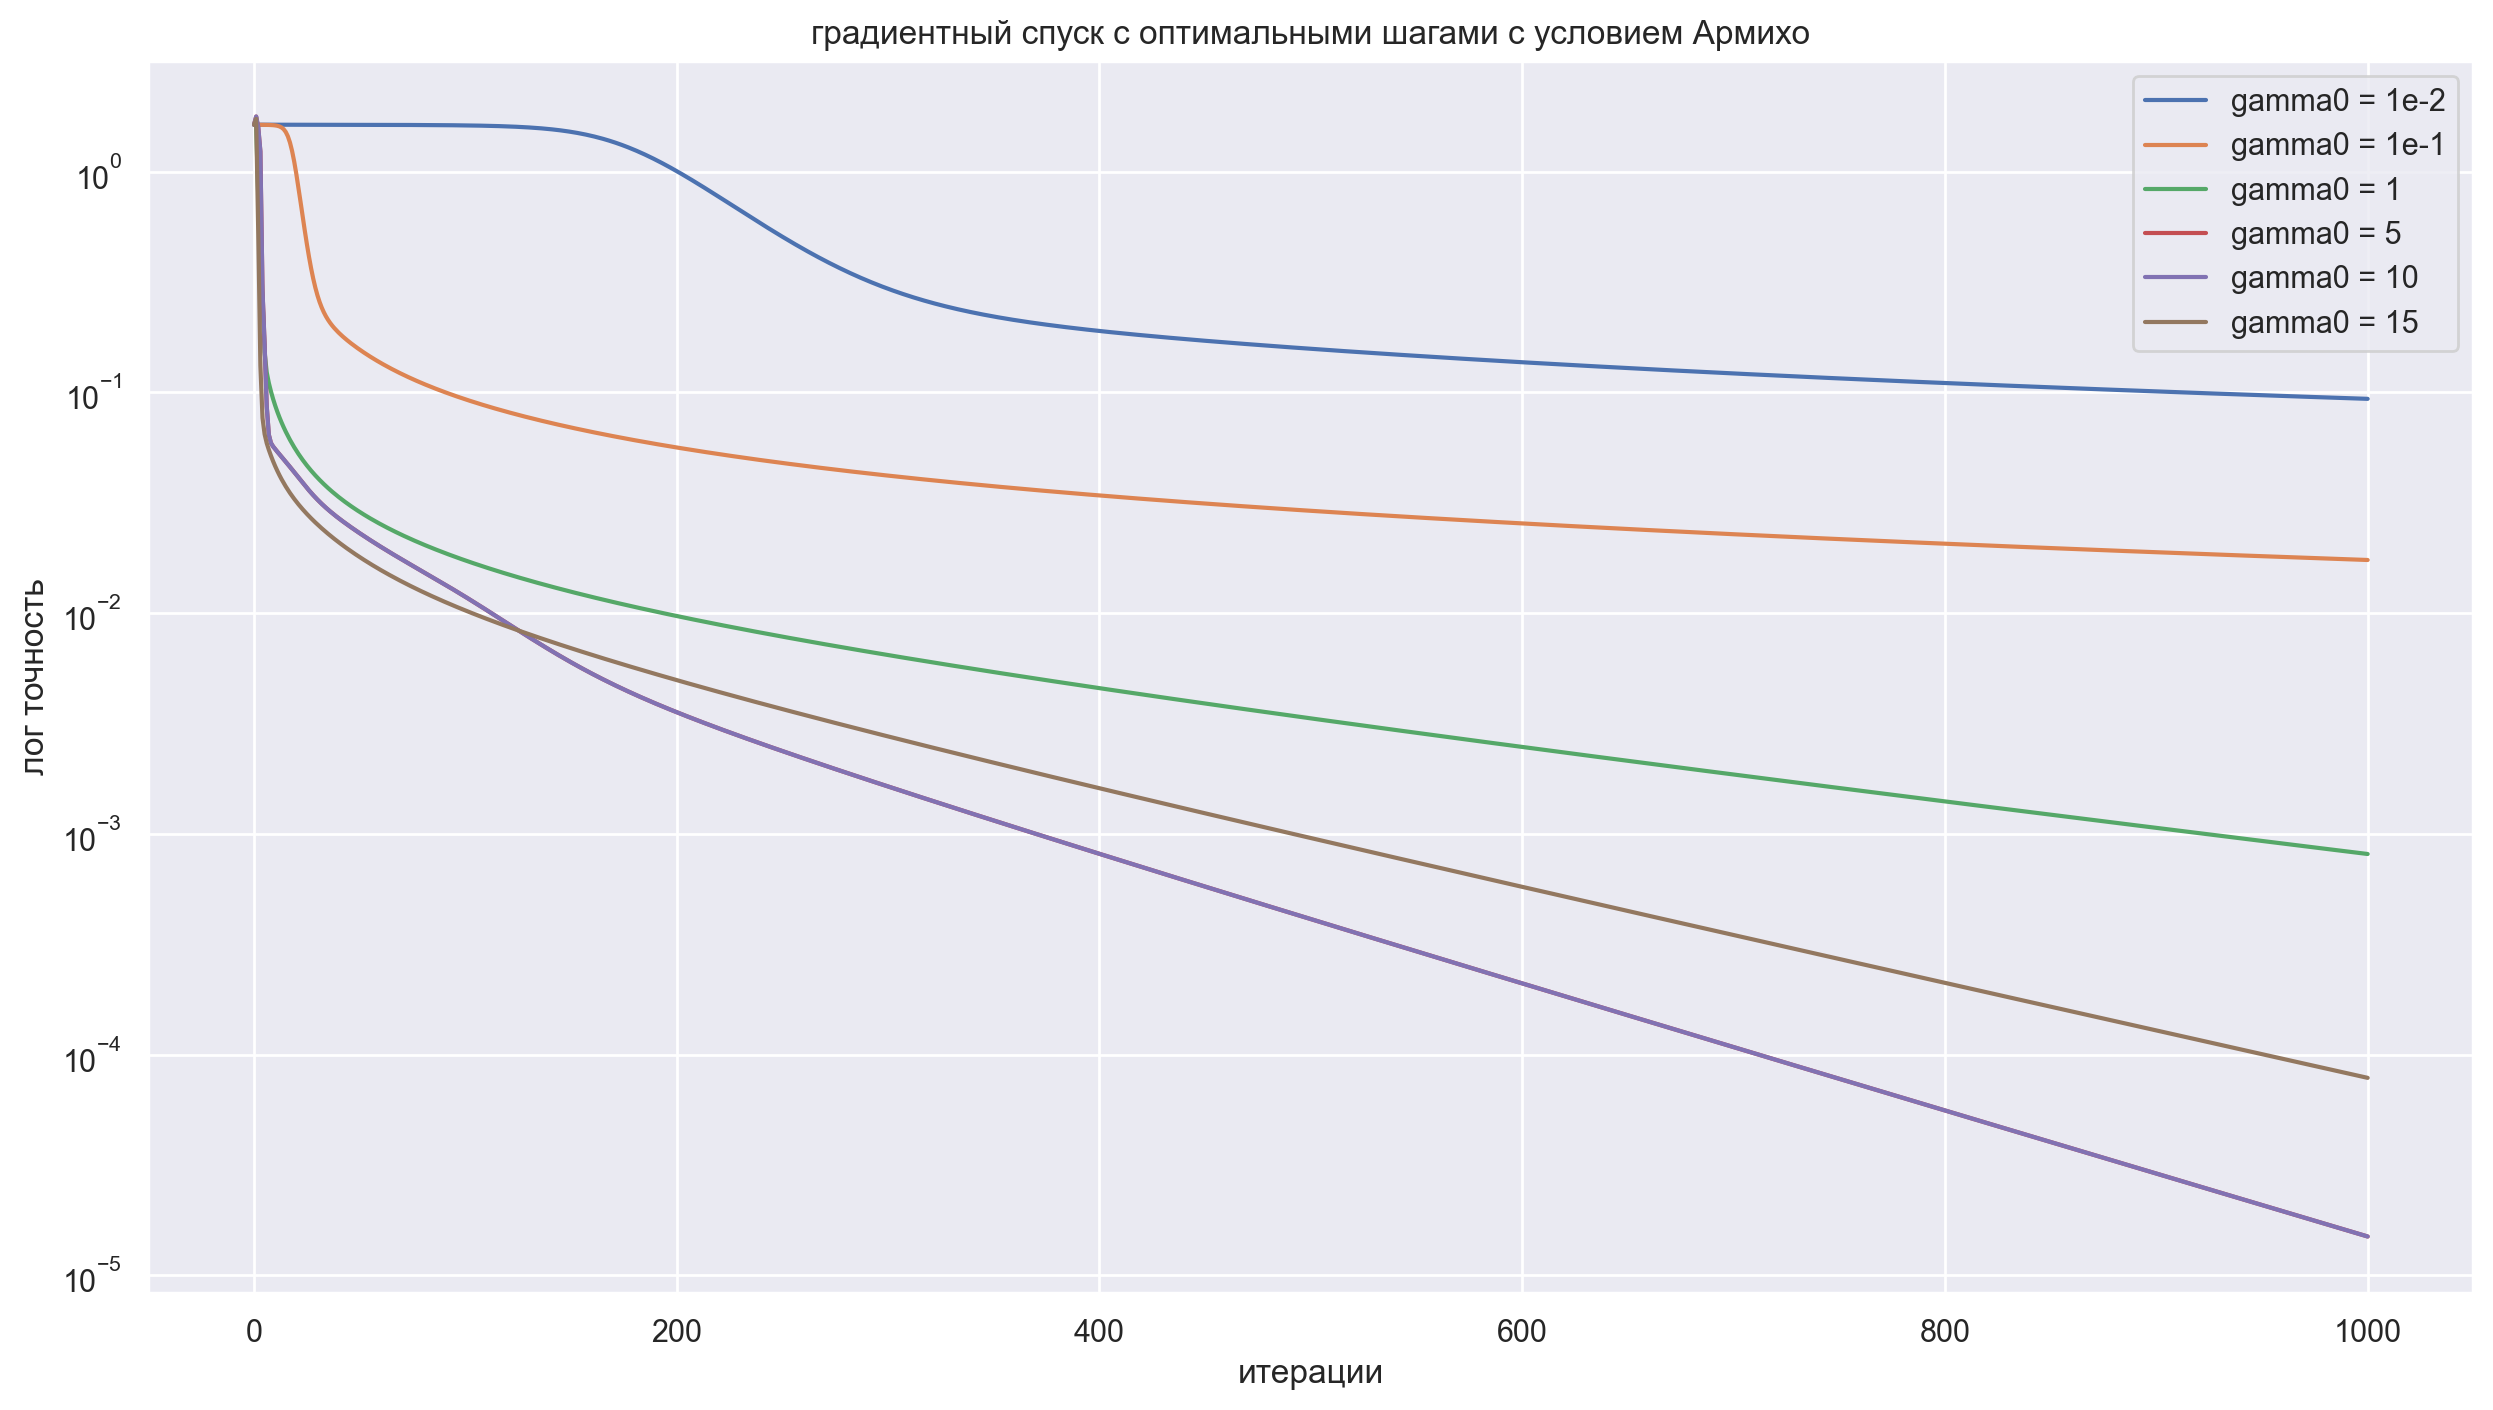

In [304]:
gamma0_list = [1e-2, 1e-1, 1, 5, 10, 15] 
gamma0_label_list = ["1e-2", "1e-1", "1", "5", "10", "15"] 
lambda_value = L / 1000
max_iter = 1000
eps = 1e-8
beta1 = 1e-4
m = 0.5
line_search_max_iter = 100

plt.figure(figsize = (15 ,8))

for i, gamma0_i in enumerate(gamma0_list):
  x_k, values, errors = gradient_descent_optimal_steps(A_train, b_train, lambda_value, loss, grad, armijo, criterion, x_0, eps, max_iter, \
                                                  beta1=beta1, beta2=0, gamma_mult=m, line_search_max_iter=line_search_max_iter, gamma0=gamma0_i)
  grid = np.arange(len(errors))
  plt.plot(grid, errors, label=f"gamma0 = {gamma0_label_list[i]}")
  
plt.yscale("log")
plt.title("градиентный спуск с оптимальными шагами с условием Армихо")
plt.legend()
plt.xlabel("итерации")
plt.ylabel("лог точность")
plt.show()

Почему наблюдается худшая сходимость при меньших значений $\gamma_0$?

In [ ]:
2 / (L + mu)

np.float64(0.77234931032423)

#### Ваше решение (Markdown)

при малых значениях $gamma0$ условие Армихо практически всегда выполняется, поэтому оно не оказывает особого. Но по сравнению с оптимальным шагом в обычном градиентном спуске, $10^{-2}, 10^{-1} - $слишком малы, и по сути мы делаем слишком консервативные шаги

а с большими шагами все просто. Мы берем большие шаги чтобы быстрее добиратся до минимума, а также проверям по условию Армихо - что мы точно минимизируем функцию на следующем шаге (в следствее шаг не заставляет метод расходится)

__б) (2 балла)__ Хоть правило Армихо и отсекает некоторое количество неудачных шагов, всё же оно не определяет шаг строго — остаётся достаточно широкий выбор допустимых значений $\gamma$, удовлетворяющих неравенству. Это может привести к выбору слишком малого шага, особенно если взять $\gamma$ достаточно маленьким с самого начала — тогда условие Армихо будет выполнено, но скорость сходимости существенно снизится. Вы могли убедиться в этом в предыдущем пункте, где даже слишком маленький шаг удовлетворял критерию.

Чтобы избежать этой проблемы, используется _правило Гольдштейна_, которое сужает диапазон допустимых значений $\gamma$, добавляя нижнюю границу на приращение функции. Оно использует ту же линейную аппроксимацию, но требует, чтобы значение функции не было слишком маленьким — то есть, чтобы шаг не оказался чересчур осторожным. Условие Гольдштейна выглядит следующим образом:

$$
f\left(x^k\right) + \beta_2 \gamma_k \langle \nabla f\left(x^k\right), h^k \rangle \leq f\left(x^k + \gamma_k h^k\right) \leq f\left(x^k\right) + \beta_1 \gamma_k \langle \nabla f\left(x^k\right), h^k \rangle,
$$

где $0 < \beta_1 < \beta_2 < 1$. Таким образом, выбираются такие $\gamma$, которые дают достаточное, но не чрезмерное убывание функции. Это может значительно ускорить сходимость, особенно на начальных этапах, когда длина шага критична для быстрого продвижения к минимуму.

**Псевдокод алгоритма**

---

_Инициализация:_

- Начальная точка $x^k$
- Начальная точка $\gamma_0 > 0$
- Направление спуска $h^k$
- Максимальное число итераций $K$
- Множитель уменьшения шага $m \in (0, 1)$
- Параметры $\beta_1, \beta_2 \in (0, 1)$

---

1. Проверить условие Гольдштейна:

$$
f\left(x^k\right) + \beta_2 \gamma_k \langle \nabla f\left(x^k\right), h^k \rangle \leq f\left(x^k + \gamma_k h^k\right) \leq f\left(x^k\right) + \beta_1 \gamma_k \langle \nabla f\left(x^k\right), h^k \rangle
$$

2. Если условие выполнено — вернуть $\gamma_k$. Иначе — уменьшить шаг:

    $$
    \gamma_k = m \cdot \gamma_k
    $$

    и вернуться к 1

---

_Условие остановки:_
- Достигнуто максимальное число итераций $K$

---

_Выход:_
- Полученное значение $\gamma_k$

In [306]:
def goldstein(A, b, lambda_value, loss, grad, x, h, beta1, beta2, gamma_mult, max_iters, gamma0):
    """
    Правило Гольдштейна.

    Параметры:
        A (np.array): Матрица признаков
        b (np.array): Вектор целевых значений
        lambda_value (float): Параметр регуляризации
        loss (Callable): Функция потерь f(x)
        grad (Callable): Функция вычисления градиента ∇f(x)
        x (np.array): Текущая точка
        h (np.array): Направление спуска (обычно -∇f(x))
        beta1 (float): Параметр условия достаточного убывания (обычно 1e-4)
        beta2 (float): Не используется, оставлен для совместимости, по умолчанию 0
        gamma_mult (float): Множитель уменьшения шага (обычно 0.5)
        max_iters (int): Максимальное число итераций подбора (обычно 100)
        gamma0 (float): Начальное значение шага

    Возвращает:
        gamma (float): Найденное значение шага, удовлетворяющее условию Гольдштейна
    """
    gamma = gamma0
    counter = 0
    current_loss = loss(x, A, b, lambda_value)
    grad_x = grad(x, A, b, lambda_value)
    directional_derivative = grad_x.dot(h)

    while counter < max_iters:
        first = current_loss + beta2*gamma*directional_derivative
        second = loss(x + gamma*h, A, b, lambda_value)
        third = current_loss + beta1*gamma*directional_derivative

        if((first <= second) and (second <= third)):
            break
        gamma = gamma_mult * gamma

        counter += 1

    return gamma

    

Запустите правило Гольдштейна с параметрами $\gamma_0$ из __а)__. В качестве множителя уменьшения шага рассмотрите $m = 0.5$. В качестве параметров $\beta_1$ и $\beta_2$ возьмите $\beta_1 = 10^{-4}$ и $\beta_2 = 1 - 10^{-4}$.

100%|██████████| 1000/1000 [00:06<00:00, 150.96it/s]


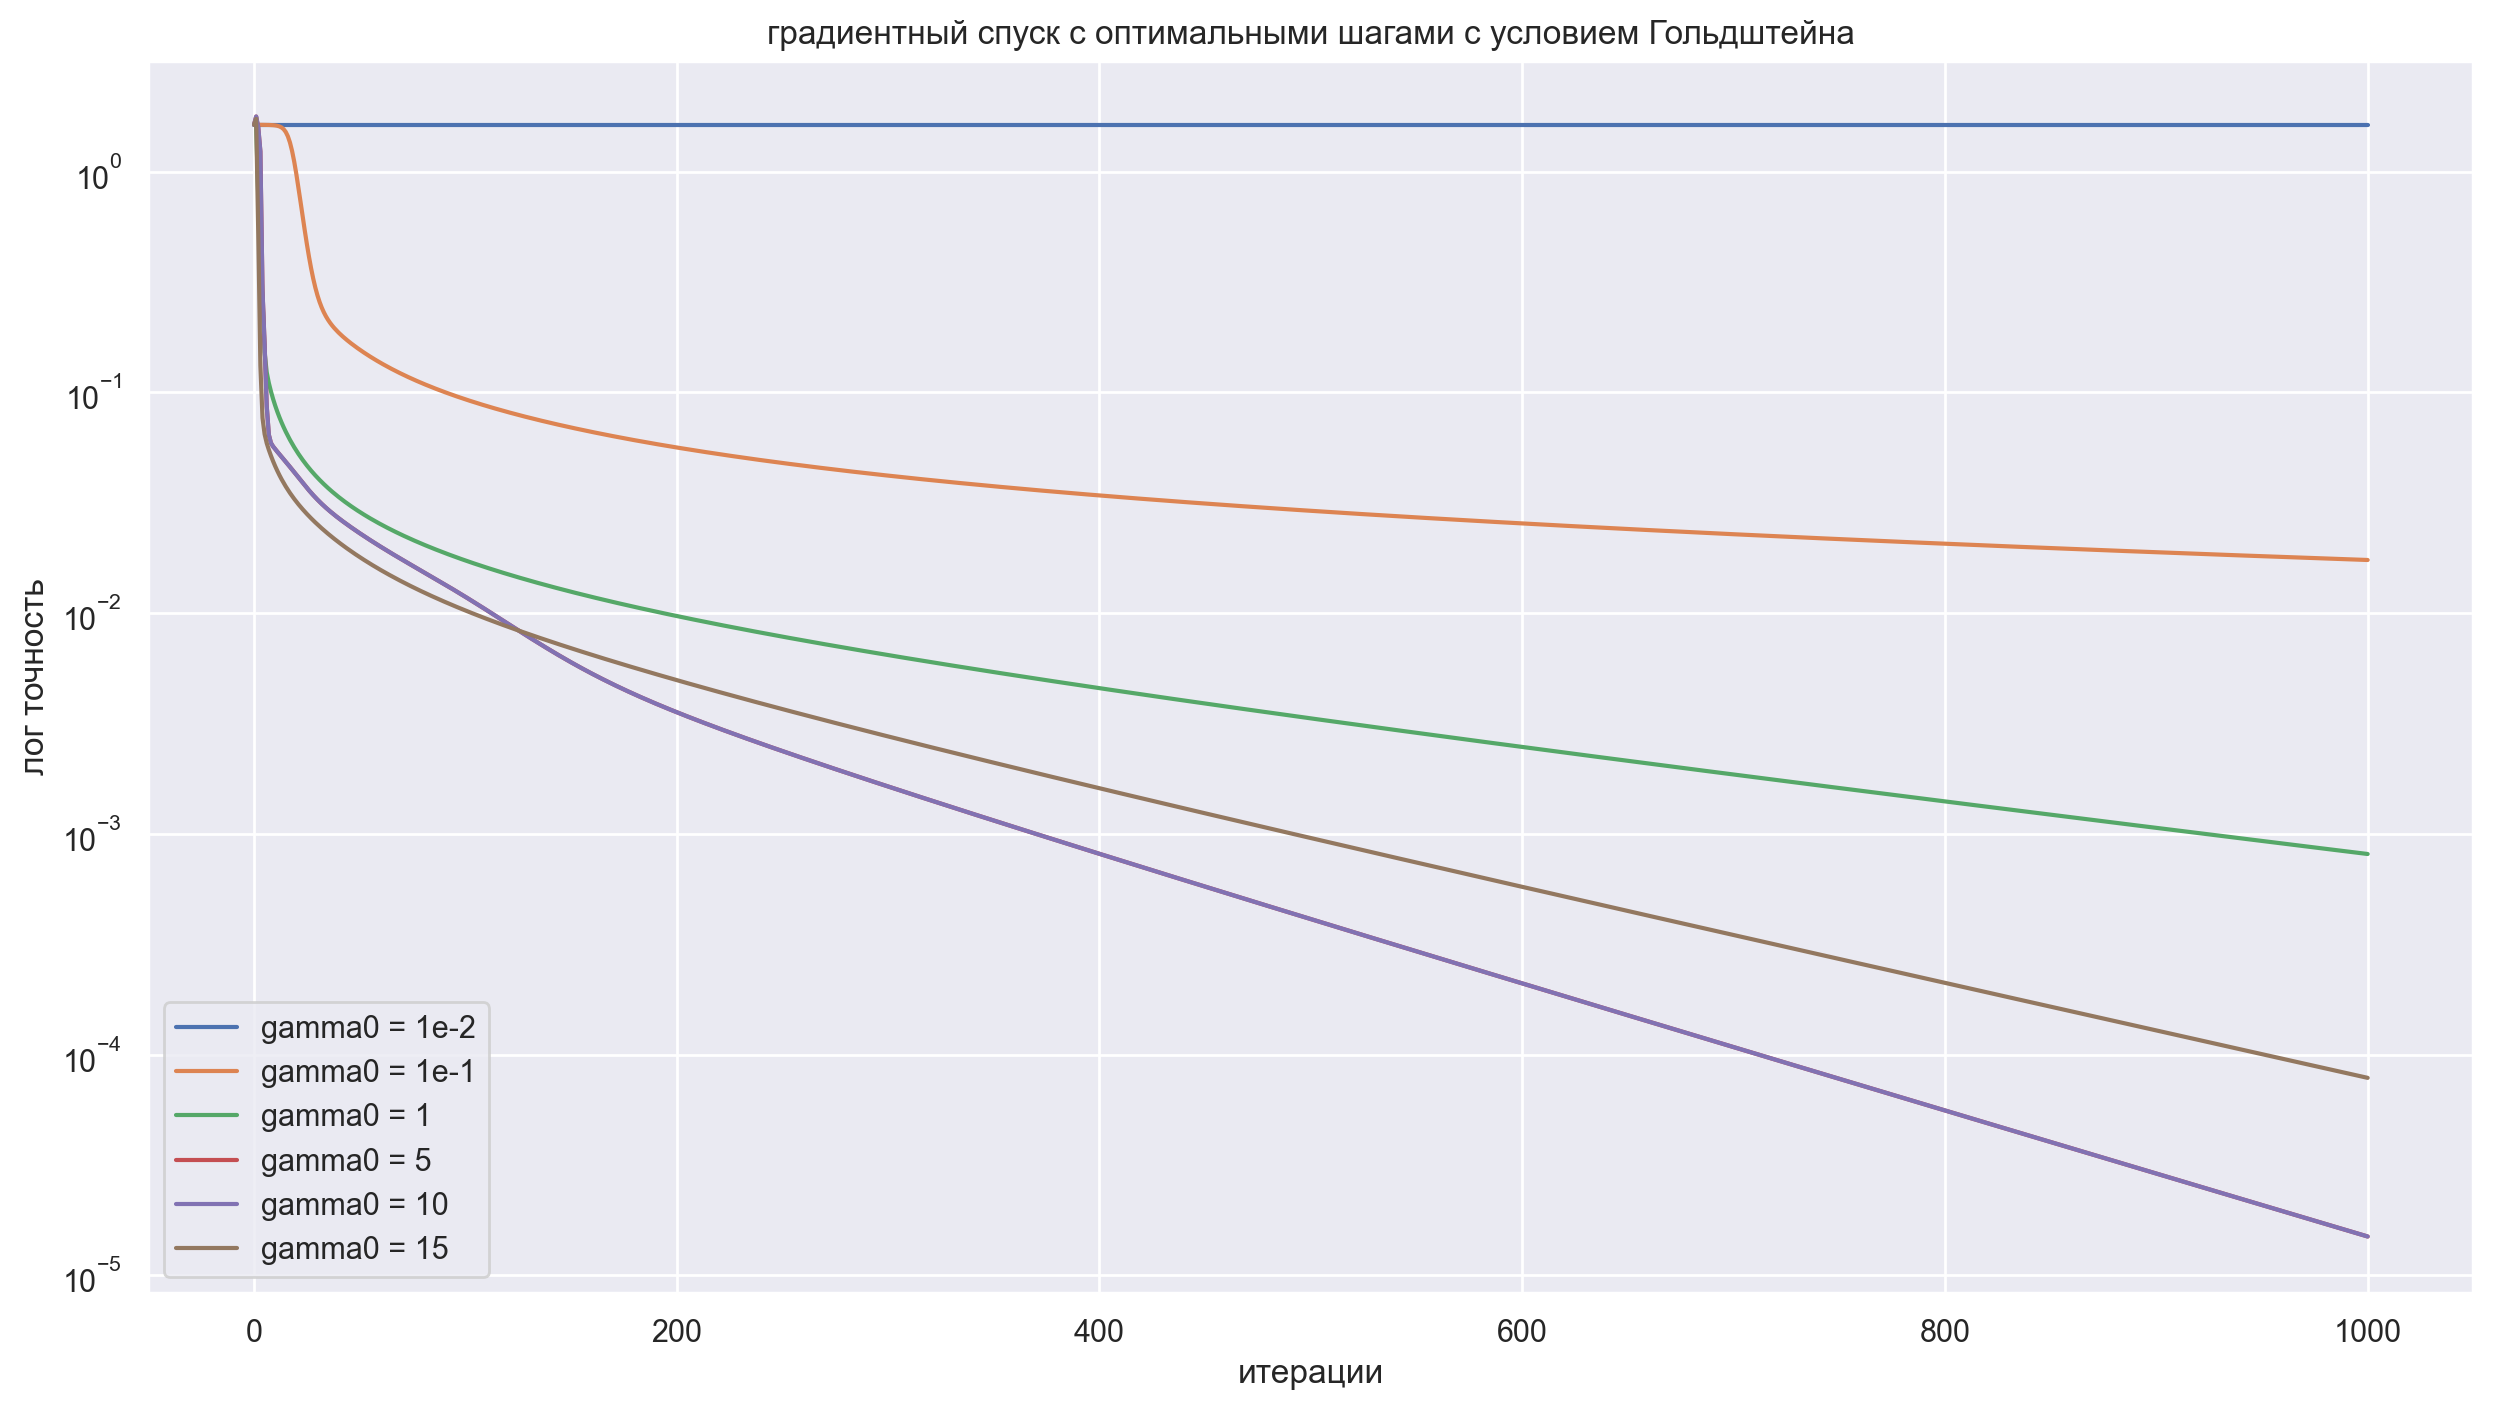

In [313]:
gamma0_list = [1e-2, 1e-1, 1, 5, 10, 15] 
gamma0_label_list = ["1e-2", "1e-1", "1", "5", "10", "15"] 
lambda_value = L / 1000
max_iter = 1000
eps = 1e-8
beta1 = 1e-4
beta2 = 1 - 1e-4
m = 0.5
line_search_max_iter = 100

plt.figure(figsize = (15 ,8))

for i, gamma0_i in enumerate(gamma0_list):
  x_k, values, errors = gradient_descent_optimal_steps(A_train, b_train, lambda_value, loss, grad, goldstein, criterion, x_0, eps, max_iter, \
                                                  beta1=beta1, beta2=beta2, gamma_mult=m, line_search_max_iter=line_search_max_iter, gamma0=gamma0_i)
  grid = np.arange(len(errors))
  plt.plot(grid, errors, label=f"gamma0 = {gamma0_label_list[i]}")
  
plt.yscale("log")
plt.title("градиентный спуск с оптимальными шагами с условием Гольдштейна")
plt.legend()
plt.xlabel("итерации")
plt.ylabel("лог точность")
plt.show()

Есть ли улучшение сходимости? Объясните, почему.

#### Ваше решение (Markdown)

Посути мы ничего не улучшили. Мы просто наивно отсекали область gamma0, но видимо при использовании метода Армихо у нас не возникали проблемы с попаданием в эту область. Изменения видны только для мелких значении gamma0

__в) (2 балла)__ Условие Гольдштейна реализует наивное отсечение. Теперь рассмотрим точки, в которых наша функция не убывает так сильно, как в текущей. Конкретнее, нас интересуют такие значения шага, при которых производная по направлению $h^k$ не уменьшилась сильно по сравнению с тем, что было в начале, то есть:

$$
\langle \nabla f \left(x^k + \gamma_k h^k\right),  h^k \rangle \geq \beta_2 \langle \nabla f \left(x^k\right), h^k \rangle.
$$

Это условие называется условием кривизны (curvature condition). Его смысл — убедиться, что градиент в новой точке не стал слишком плоским по направлению $h^k$, то есть мы не зашли слишком далеко в область, где функция уже почти не меняется. Такое поведение может привести к медленной сходимости и ухудшению качества шага.

Правило Вольфа объединяет два требования: условие Армихо, которое гарантирует достаточное убывание функции, и условие кривизны, которое ограничивает чрезмерное затухание производной. Таким образом, шаг выбирается только в том случае, если оба этих условия выполняются одновременно.

**Псевдокод алгоритма**

---

_Инициализация:_

- Начальная точка $x^k$
- Начальная точка $\gamma_0 > 0$
- Направление спуска $h^k$
- Максимальное число итераций $K$
- Множитель уменьшения шага $m \in (0, 1)$
- Параметры $\beta_1, \beta_2 \in (0, 1)$

---

1. Проверить условие Армихо:

$$
f\left(x^k + \gamma_k h^k\right) \leq f\left(x^k\right) + \beta_1 \gamma_k \langle \nabla f\left(x^k\right), h^k \rangle
$$

2. Проверить условие кривизны

$$
\langle \nabla f \left(x^k + \gamma_k h^k\right),  h^k \rangle \geq \beta_2 \langle \nabla f \left(x^k\right), h^k \rangle
$$

2. Если оба условия выполняются, вернуть $\gamma_k$. Если не выполняется Армихо — уменьшить шаг:

    $$\gamma_k = \gamma_k \cdot m$$

    и вернуться к 1. Иначе — увеличить шаг:

    $$\gamma_k = \gamma_k / m$$

    и вернуться к 1

---

_Условие остановки:_
- Достигнуто максимальное число итераций $K$

---

_Выход:_
- Полученное значение $\gamma_k$

In [333]:
def wolfe(A, b, lambda_value, loss, grad, x, h, beta1, beta2, gamma_mult, max_iters, gamma0):
    """
    Правило Вольфа.

    Параметры:
        A (np.array): Матрица признаков
        b (np.array): Вектор целевых значений
        lambda_value (float): Параметр регуляризации
        loss (Callable): Функция потерь f(x)
        grad (Callable): Функция вычисления градиента ∇f(x)
        x (np.array): Текущая точка
        h (np.array): Направление спуска (обычно -∇f(x))
        beta1 (float): Параметр условия достаточного убывания (обычно 1e-4)
        beta2 (float): Не используется, оставлен для совместимости, по умолчанию 0
        gamma_mult (float): Множитель уменьшения шага (обычно 0.5)
        max_iters (int): Максимальное число итераций подбора (обычно 100)
        gamma0 (float): Начальное значение шага

    Возвращает:
        gamma (float): Найденное значение шага, удовлетворяющее условию Гольдштейна
    """
    gamma = gamma0
    counter = 0
    current_loss = loss(x, A, b, lambda_value)
    grad_x = grad(x, A, b, lambda_value)
    directional_derivative = grad_x.dot(h)

    while counter < max_iters:
        new_loss = loss(x + gamma * h, A, b, lambda_value)
        grad_new_x = grad(x + gamma * h, A, b, lambda_value)
        new_directional_derivative = grad_new_x.dot(h)


        first_condition = (new_loss <= current_loss + beta1*gamma*directional_derivative)
        second_condition = (new_directional_derivative >= beta2*directional_derivative)

        if first_condition and second_condition:
            break
        
        if not first_condition:
            gamma = gamma * gamma_mult
        else:
            gamma =  gamma / gamma_mult
        counter += 1
        
    return gamma

Запустите правило Вольфа с параметрами $\gamma_0$ из __а)__. В качестве множителя уменьшения шага рассмотрите $m = 0.5$. В качестве параметров $\beta_1$ и $\beta_2$ возьмите $\beta_1 = 10^{-4}$ и $\beta_2 = 0.9$.

 66%|██████▌   | 658/1000 [00:09<00:04, 72.33it/s]


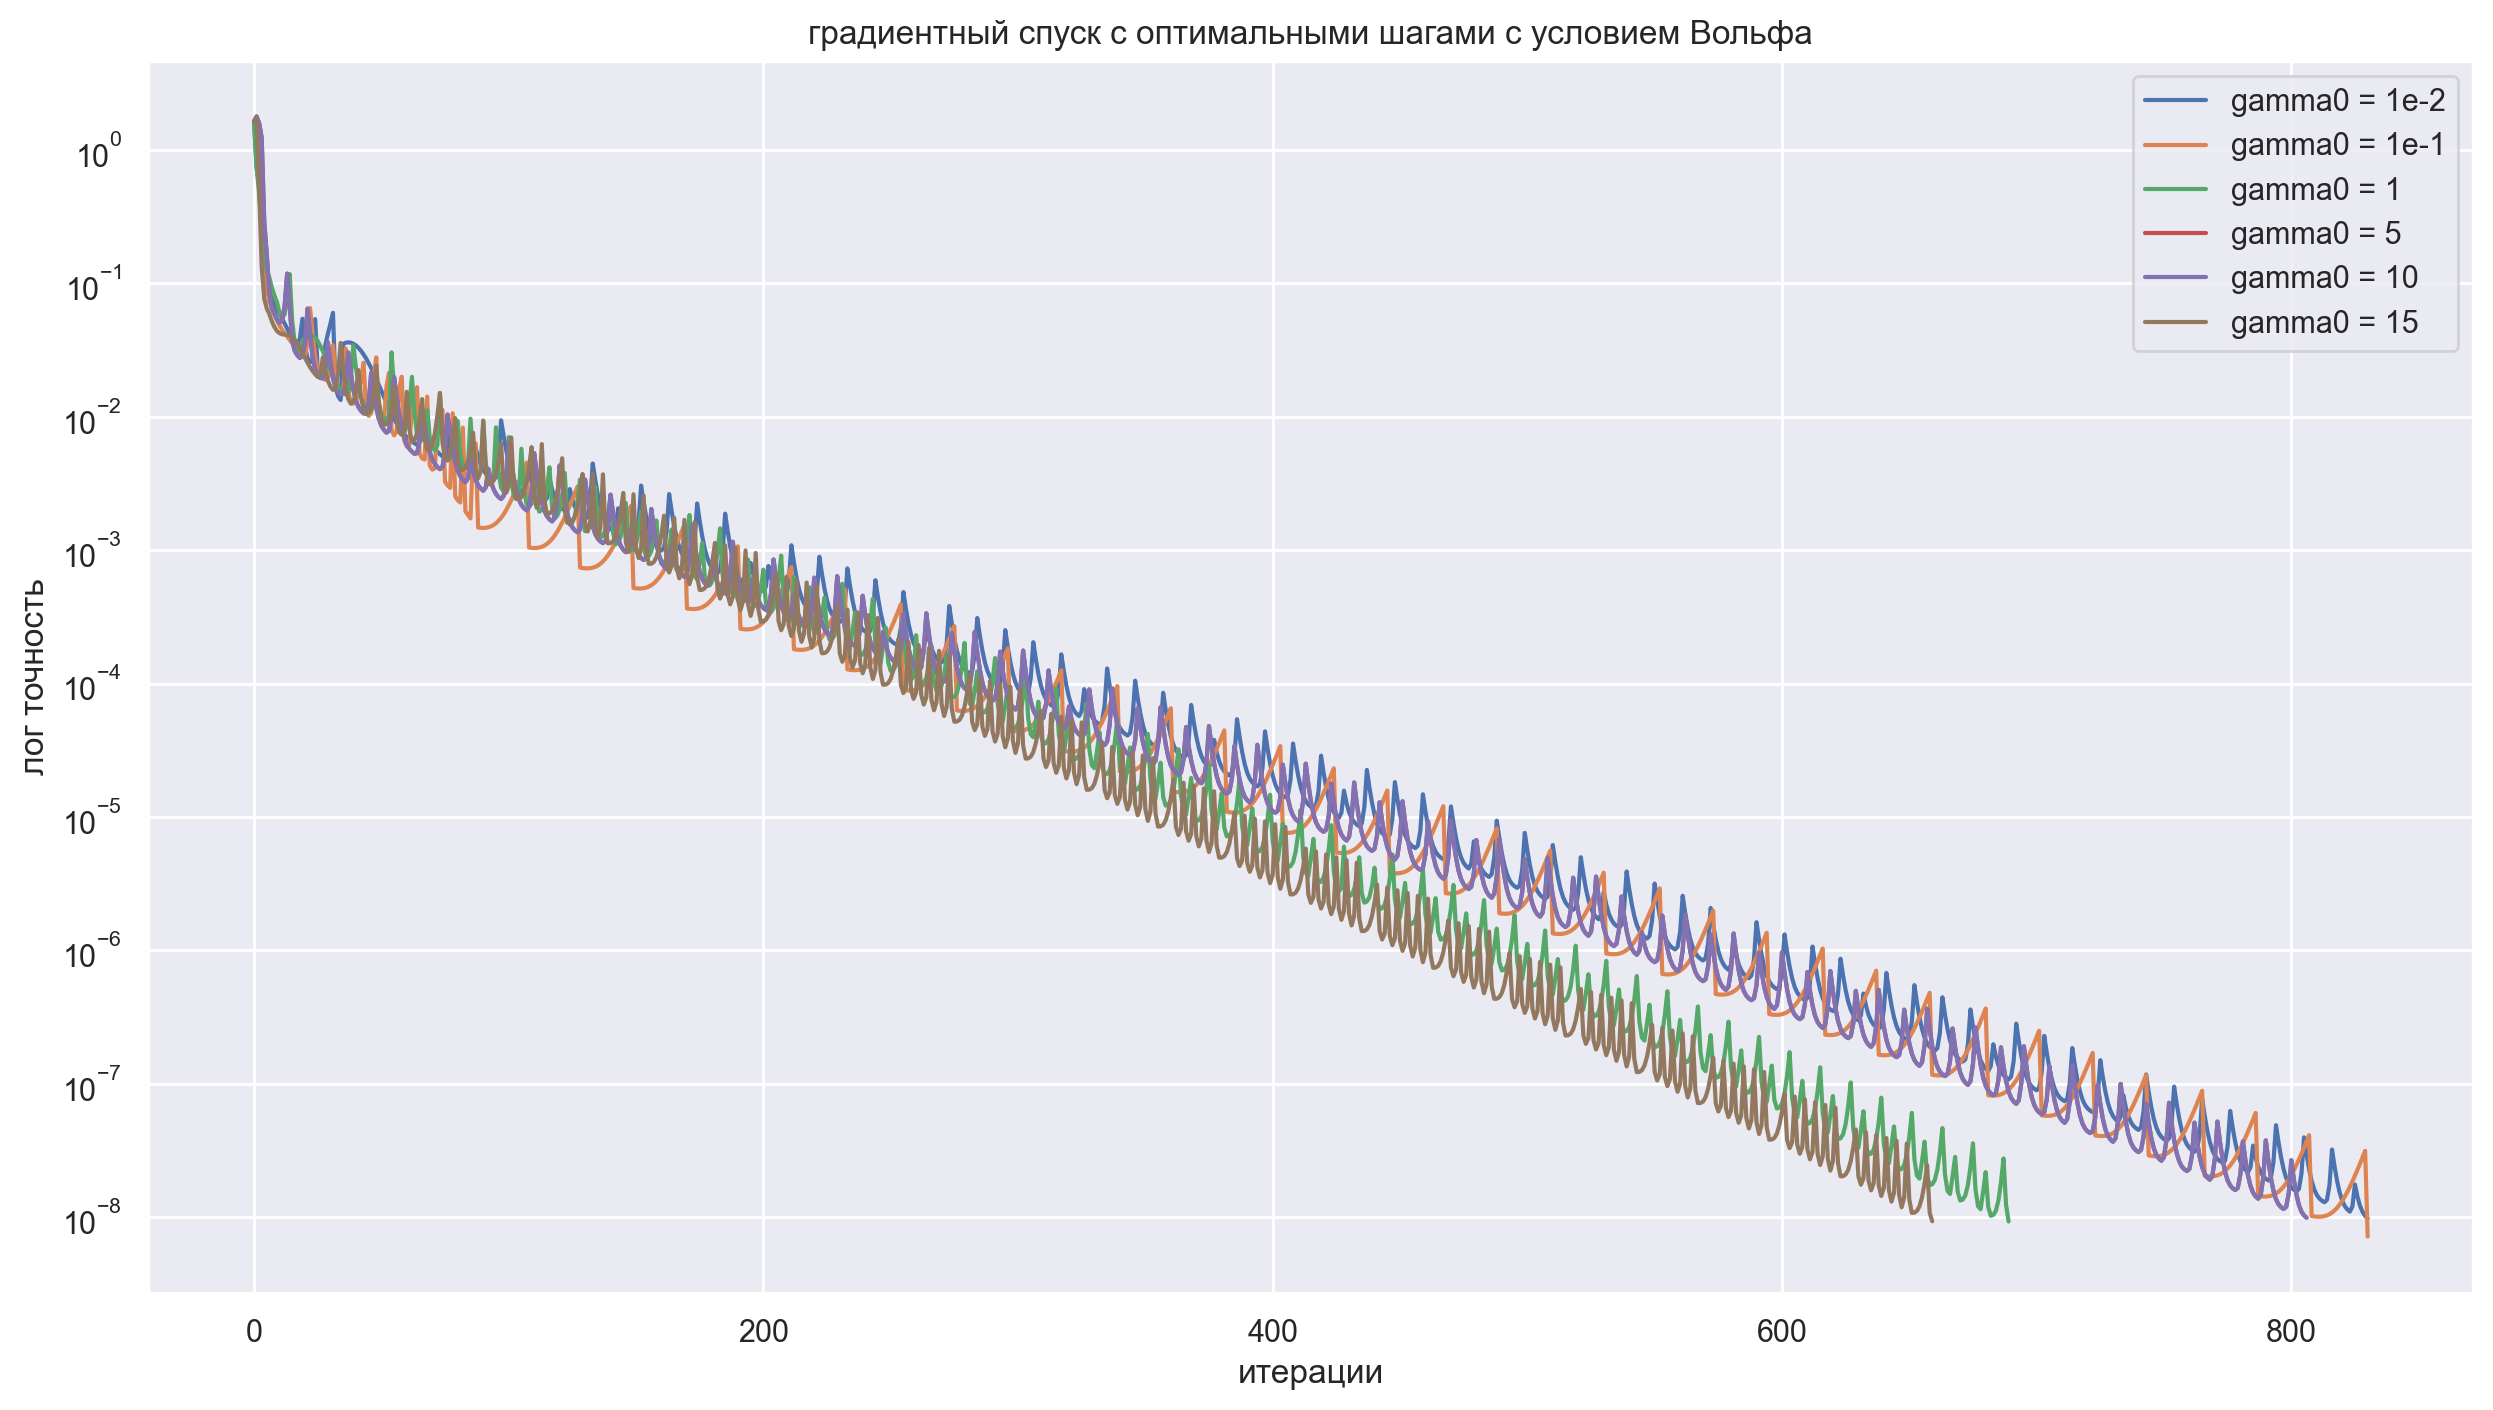

In [334]:
gamma0_list = [1e-2, 1e-1, 1, 5, 10, 15] 
gamma0_label_list = ["1e-2", "1e-1", "1", "5", "10", "15"] 
lambda_value = L / 1000
max_iter = 1000
eps = 1e-8
beta1 = 1e-4
beta2 = 0.9
m = 0.5
line_search_max_iter = 100

plt.figure(figsize = (15 ,8))

for i, gamma0_i in enumerate(gamma0_list):
  x_k, values, errors = gradient_descent_optimal_steps(A_train, b_train, lambda_value, loss, grad, wolfe, criterion, x_0, eps, max_iter, \
                                                  beta1=beta1, beta2=beta2, gamma_mult=m, line_search_max_iter=line_search_max_iter, gamma0=gamma0_i)
  grid = np.arange(len(errors))
  plt.plot(grid, errors, label=f"gamma0 = {gamma0_label_list[i]}")
  
plt.yscale("log")
plt.title("градиентный спуск с оптимальными шагами с условием Вольфа")
plt.legend()
plt.xlabel("итерации")
plt.ylabel("лог точность")
plt.show()

Результаты хорошие, почти как у Ускоренного градиентного спуска (для маленьких значении gamma0 нужно чуть больше итерации, но все же, теперь они хорошо сходятся)

__г) (2 балла)__ Обычное условие кривизны может допускать ситуацию, когда производная по направлению в новой точке становится положительной, что приводит к тому, что неравенство всегда выполняется. Чтобы исключить этот случай, можно использовать модули для проверки абсолютного значения градиента:

$$
|\langle \nabla f \left(x^k + \gamma_k h^k\right),  h^k \rangle| \leq \beta_2 |\langle \nabla f \left(x^k\right), h^k \rangle|.
$$

Знак меняется, потому что справа мы имеем отрицательное значение, которое становится положительным. Мы хотим, чтобы абсолютное значение производной в новой точке было близким к нулю, так как в оптимуме градиент должен быть равен нулю, а это гарантирует, что шаг был выбран правильно и направлен в сторону минимума.

**Псевдокод алгоритма**

---

_Инициализация:_

- Начальная точка $x^k$
- Начальная точка $\gamma_0 > 0$
- Направление спуска $h^k$
- Максимальное число итераций $K$
- Множитель уменьшения шага $m \in (0, 1)$
- Параметры $\beta_1, \beta_2 \in (0, 1)$

---

1. Проверить условие Армихо:

$$
f\left(x^k + \gamma_k h^k\right) \leq f\left(x^k\right) + \beta_1 \gamma_k \langle \nabla f\left(x^k\right), h^k \rangle
$$

2. Проверить сильное условие кривизны

$$
|\langle \nabla f \left(x^k + \gamma_k h^k\right),  h^k \rangle| \leq \beta_2 |\langle \nabla f \left(x^k\right), h^k \rangle|
$$

2. Если оба условия выполняются, вернуть $\gamma_k$. Если не выполняется Армихо или направление положительное — уменьшить шаг:

    $$\gamma_k = \gamma_k \cdot m$$

    и вернуться к 1. Иначе — увеличить шаг:

    $$\gamma_k = \gamma_k / m$$

    и вернуться к 1

---

_Условие остановки:_
- Достигнуто максимальное число итераций $K$

---

_Выход:_
- Полученное значение $\gamma_k$

In [336]:
def strong_wolfe(A, b, lambda_value, loss, grad, x, h, beta1, beta2, gamma_mult, max_iters, gamma0):
    """
    Сильное правило Вольфа.

    Параметры:
        A (np.array): Матрица признаков
        b (np.array): Вектор целевых значений
        lambda_value (float): Параметр регуляризации
        loss (Callable): Функция потерь f(x)
        grad (Callable): Функция вычисления градиента ∇f(x)
        x (np.array): Текущая точка
        h (np.array): Направление спуска (обычно -∇f(x))
        beta1 (float): Параметр условия достаточного убывания (обычно 1e-4)
        beta2 (float): Не используется, оставлен для совместимости, по умолчанию 0
        gamma_mult (float): Множитель уменьшения шага (обычно 0.5)
        max_iters (int): Максимальное число итераций подбора (обычно 100)
        gamma0 (float): Начальное значение шага

    Возвращает:
        gamma (float): Найденное значение шага, удовлетворяющее условию Гольдштейна
    """
    gamma = gamma0
    counter = 0
    current_loss = loss(x, A, b, lambda_value)
    grad_x = grad(x, A, b, lambda_value)
    directional_derivative = grad_x.dot(h)

    while counter < max_iters:
        new_loss = loss(x + gamma * h, A, b, lambda_value)
        grad_new_x = grad(x + gamma * h, A, b, lambda_value)
        new_directional_derivative = grad_new_x.dot(h)


        first_condition = (new_loss <= current_loss + beta1*gamma*directional_derivative)
        second_condition = (np.abs(new_directional_derivative) <= np.abs(beta2*directional_derivative))

        if first_condition and second_condition:
            break
        
        if not first_condition:
            gamma = gamma * gamma_mult
        else:
            gamma =  gamma / gamma_mult
        counter += 1
    return gamma

Запустите правило усиленного Вольфа с параметрами $\gamma_0$ из __а)__. В качестве множителя уменьшения шага рассмотрите $m = 0.5$. В качестве параметров $\beta_1$ и $\beta_2$ возьмите $\beta_1 = 10^{-4}$ и $\beta_2 = 0.9$.

 66%|██████▌   | 658/1000 [00:09<00:05, 67.12it/s]


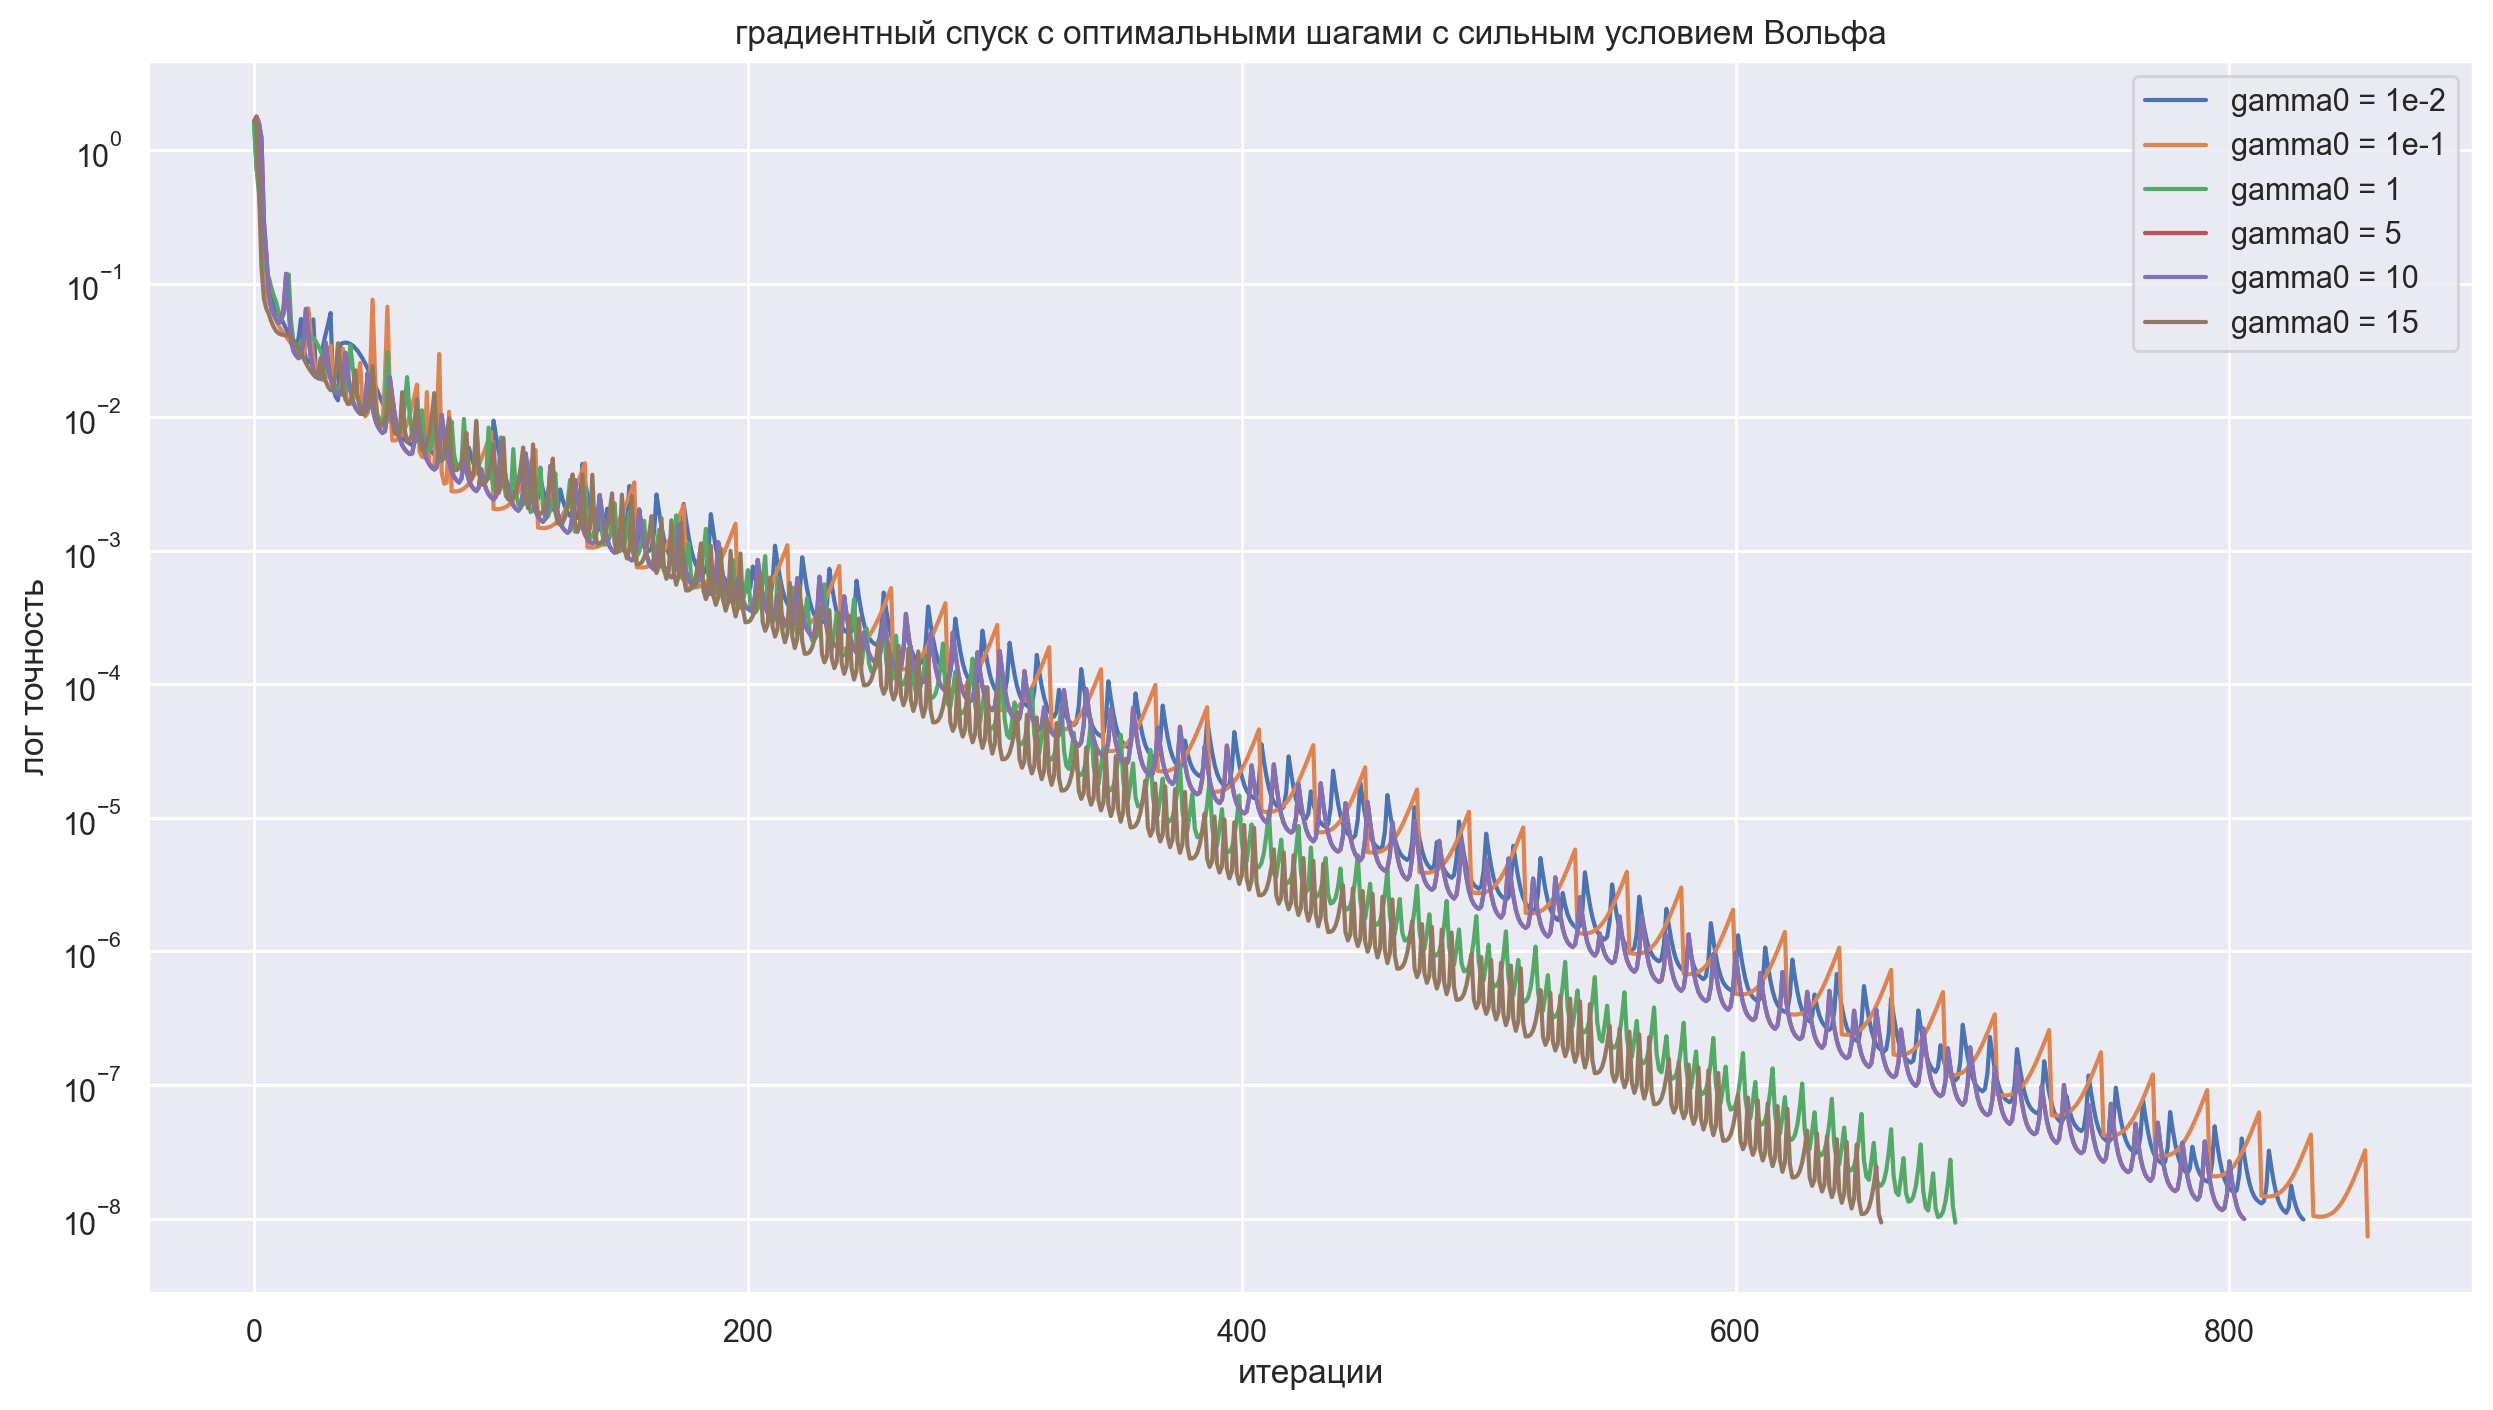

In [337]:
gamma0_list = [1e-2, 1e-1, 1, 5, 10, 15] 
gamma0_label_list = ["1e-2", "1e-1", "1", "5", "10", "15"] 
lambda_value = L / 1000
max_iter = 1000
eps = 1e-8
beta1 = 1e-4
beta2 = 0.9
m = 0.5
line_search_max_iter = 100

plt.figure(figsize = (15 ,8))

for i, gamma0_i in enumerate(gamma0_list):
  x_k, values, errors = gradient_descent_optimal_steps(A_train, b_train, lambda_value, loss, grad, strong_wolfe, criterion, x_0, eps, max_iter, \
                                                  beta1=beta1, beta2=beta2, gamma_mult=m, line_search_max_iter=line_search_max_iter, gamma0=gamma0_i)
  grid = np.arange(len(errors))
  plt.plot(grid, errors, label=f"gamma0 = {gamma0_label_list[i]}")
  
plt.yscale("log")
plt.title("градиентный спуск с оптимальными шагами с сильным условием Вольфа")
plt.legend()
plt.xlabel("итерации")
plt.ylabel("лог точность")
plt.show()

__д) (2 балла)__ Сделайте итоговое сравнение методов. Постройте график и укажите, какой оказался наиболее эффективным, для следующих методов: градиентный спуск с лучшим шагом, ускоренный градиентный метод с оптимальными параметрами или градиентный спуск с адаптивным шагом (Армихо, Гольдштейн, Вольф или усиленный Вольф).

 66%|██████▌   | 658/1000 [00:08<00:04, 77.46it/s]


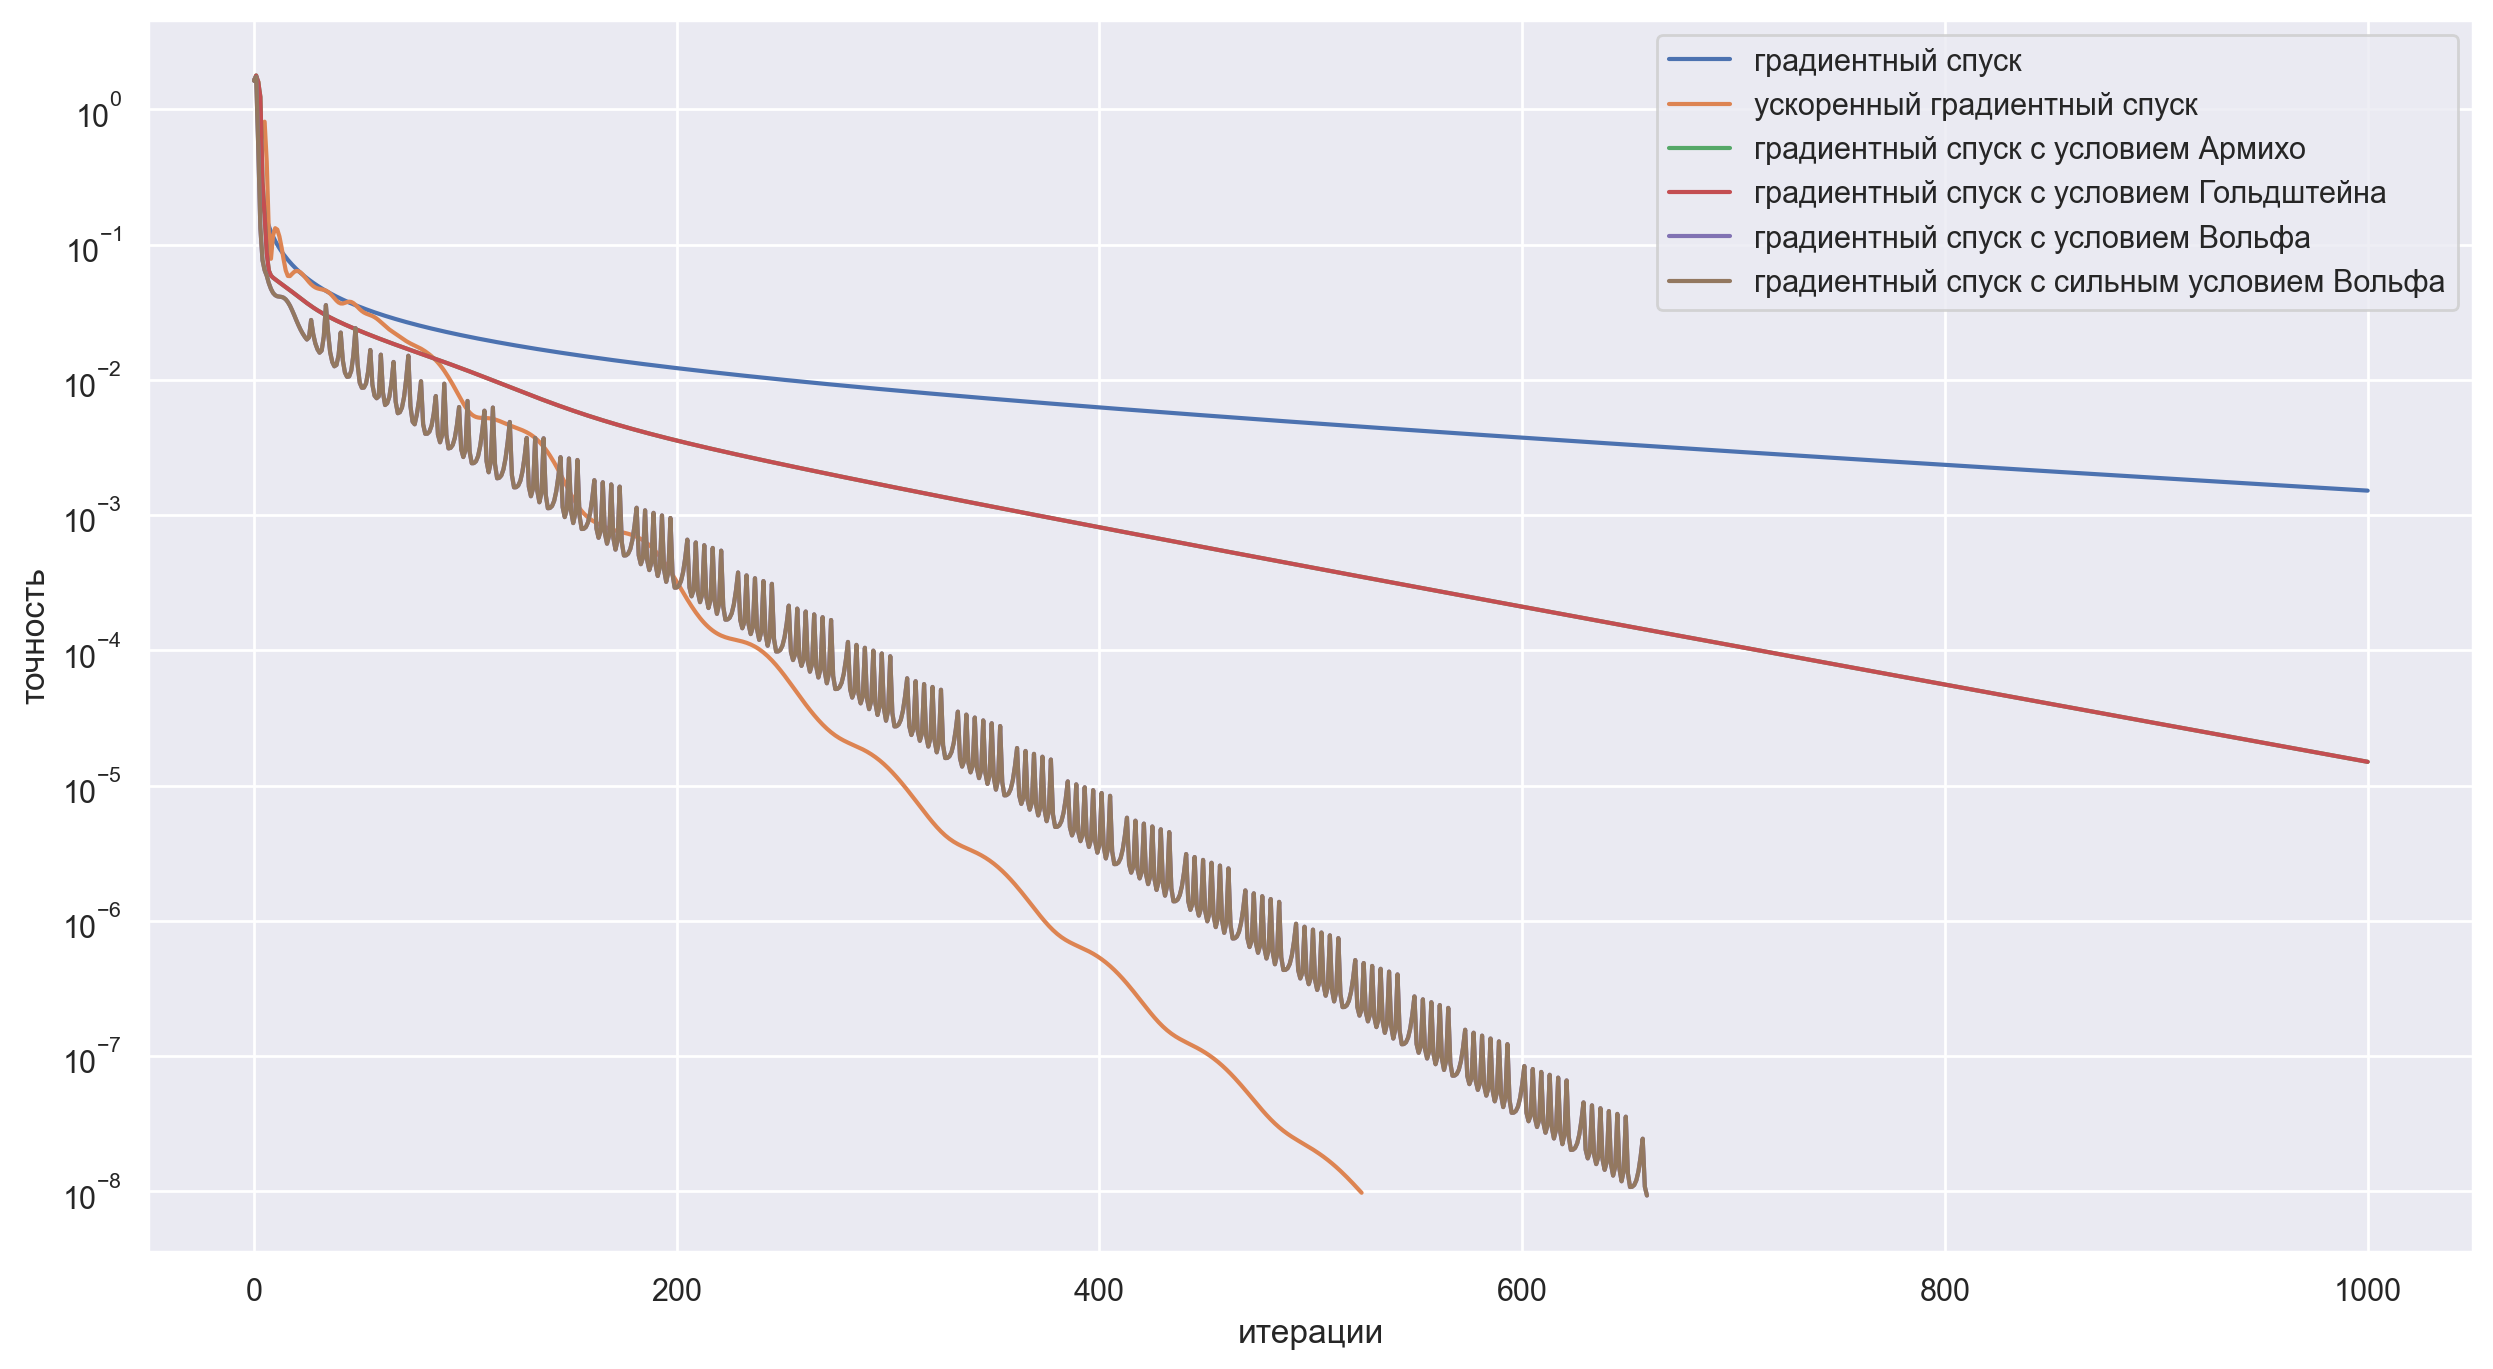

In [338]:
tau = (np.sqrt(L) - np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu))
lambda_value = L / 1000
gamma = 1/L
max_iter = 1000
eps = 1e-8

line_search_max_iter = 100
m = 0.5
gamma0_armijo = 10
beta1_armijo = 1e-4
beta2_armijo = 1 - 1e-4

gamma0_goldstein = 10
beta1_goldstein = 1e-4
beta2_goldstein = 1 - 1e-4

gamma0_wolfe = 15
beta1_wolfe = 1e-4
beta2_wolfe = 0.9


plt.figure(figsize = (15 ,8))

x_k, values, errors = gradient_descent(A_train, b_train, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=lambda k : 2 / (mu + L))
grid = np.arange(len(errors))
plt.plot(grid, errors, label="градиентный спуск")


x_k, values, errors = NAG(A_train, b_train, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=lambda x : gamma, tau=lambda x : tau)
grid = np.arange(len(errors))
plt.plot(grid, errors, label="ускоренный градиентный спуск")


x_k, values, errors = gradient_descent_optimal_steps(A_train, b_train, lambda_value, loss, grad, armijo, criterion, x_0, eps, max_iter, \
                                                beta1=beta1_armijo, beta2=beta2_armijo, gamma_mult=m, line_search_max_iter=line_search_max_iter, gamma0=gamma0_armijo)
grid = np.arange(len(errors))
plt.plot(grid, errors, label=f"градиентный спуск с условием Армихо")



x_k, values, errors = gradient_descent_optimal_steps(A_train, b_train, lambda_value, loss, grad, goldstein, criterion, x_0, eps, max_iter, \
                                                beta1=beta1_goldstein, beta2=beta2_goldstein, gamma_mult=m, line_search_max_iter=line_search_max_iter, gamma0=gamma0_goldstein)
grid = np.arange(len(errors))
plt.plot(grid, errors, label=f"градиентный спуск с условием Гольдштейна")
  

x_k, values, errors = gradient_descent_optimal_steps(A_train, b_train, lambda_value, loss, grad, wolfe, criterion, x_0, eps, max_iter, \
                                                beta1=beta1_wolfe, beta2=beta2_wolfe, gamma_mult=m, line_search_max_iter=line_search_max_iter, gamma0=gamma0_wolfe)
grid = np.arange(len(errors))
plt.plot(grid, errors, label=f"градиентный спуск с условием Вольфа")
  

x_k, values, errors = gradient_descent_optimal_steps(A_train, b_train, lambda_value, loss, grad, strong_wolfe, criterion, x_0, eps, max_iter, \
                                                beta1=beta1_wolfe, beta2=beta2_wolfe, gamma_mult=m, line_search_max_iter=line_search_max_iter, gamma0=gamma0_wolfe)
grid = np.arange(len(errors))
plt.plot(grid, errors, label=f"градиентный спуск с сильным условием Вольфа")

plt.xlabel("итерации")
plt.ylabel("точность")
plt.yscale("log")
plt.legend()
plt.show()

Поитогу ускоренный градиентный спуск с оптимальными шагами оказался лучше всех

Адаптивные методы Вольфа ведут себя более менее одинаково хорошо (но чуть хуже NAG) 

Условия Гольдштейна вместе с Армихо дают точность похуже, зато условия проверяются легче, и гамму не нужно так часто корректировать